In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import wcs
import os

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [2]:
# Open the PHANGS-MUSE Nebula Catalog FITS file
fits_file = "NGC1330.fits"

# Check if file exists
if os.path.exists(fits_file):
    print(f"Opening FITS file: {fits_file}")
    
    # Open the FITS file
    hdul = fits.open(fits_file)
    
    # Print general information about the file
    print(f"\nNumber of HDUs: {len(hdul)}")
    hdul.info()
    
else:
    print(f"File {fits_file} not found in current directory")

Opening FITS file: NGC1330.fits

Number of HDUs: 2
Filename: NGC1330.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      55   ()      
  1  PHASE3CATALOG    1 BinTableHDU    386   1472R x 75C   [12A, 7A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   


In [3]:
# Examine the headers of each HDU
for i, hdu in enumerate(hdul):
    print(f"\n{'='*50}")
    print(f"HDU {i}: {hdu.name}")
    print(f"{'='*50}")
    
    # Print header information
    print(f"Data type: {type(hdu)}")
    if hasattr(hdu, 'data') and hdu.data is not None:
        print(f"Data shape: {hdu.data.shape}")
        print(f"Data type: {hdu.data.dtype}")
    
    # Print some key header keywords
    header = hdu.header
    
    # Common keywords to look for
    keywords_to_check = ['OBJECT', 'TELESCOP', 'INSTRUME', 'CRVAL1', 'CRVAL2', 
                        'CDELT1', 'CDELT2', 'CTYPE1', 'CTYPE2', 'EXTNAME']
    
    print("\nKey header keywords:")
    for keyword in keywords_to_check:
        if keyword in header:
            print(f"  {keyword}: {header[keyword]}")
    
    # Print first few and last few header cards if it's long
    print(f"\nHeader contains {len(header)} cards")
    if len(header) > 20:
        print("First 10 header cards:")
        header_items = list(header.items())
        for j, (key, value) in enumerate(header_items[:10]):
            comment = header.comments[key]
            print(f"  {key}: {value} / {comment}")
    else:
        print("All header cards:")
        for key, value in header.items():
            comment = header.comments[key]
            print(f"  {key}: {value} / {comment}")


HDU 0: PRIMARY
Data type: <class 'astropy.io.fits.hdu.image.PrimaryHDU'>

Key header keywords:
  OBJECT: NGC 1300_Pri01
  TELESCOP: ESO-VLT-U4
  INSTRUME: MUSE

Header contains 55 cards
First 10 header cards:
  SIMPLE: True / conforms to FITS standard
  BITPIX: 8 / array data type
  NAXIS: 0 / number of array dimensions
  EXTEND: True / 
  PRODCATG: SCIENCE.CATALOGTILE / Product Category
  ORIGIN: ESO-PARANAL / European Southern Observatory
  TELESCOP: ESO-VLT-U4 / ESO <TEL>
  INSTRUME: MUSE / Instrument used
  OBJECT: NGC 1300_Pri01 / Target name
  RA: 49.921565 / offset applied!

HDU 1: PHASE3CATALOG
Data type: <class 'astropy.io.fits.hdu.table.BinTableHDU'>
Data shape: (1472,)
Data type: (numpy.record, [('SOURCE_ID', 'S12'), ('GAL_NAME', 'S7'), ('REGION_ID', '>f8'), ('RAJ2000', '>f8'), ('DECJ2000', '>f8'), ('FLAG_EDGE', '>f8'), ('FLAG_STAR', '>f8'), ('DEPROJ_PHI', '>f8'), ('REGION_AREA', '>f8'), ('HB4861_FLUX', '>f8'), ('OIII5006_FLUX', '>f8'), ('HA6562_FLUX', '>f8'), ('NII6583_FLU

In [4]:
# Analyze data structure for each HDU
for i, hdu in enumerate(hdul):
    if hasattr(hdu, 'data') and hdu.data is not None:
        data = hdu.data
        print(f"\nAnalyzing data in HDU {i} ({hdu.name}):")
        print(f"  Shape: {data.shape}")
        print(f"  Data type: {data.dtype}")
        
        # Check if this is a structured array (table/catalog)
        if data.dtype.names is not None:
            print(f"  -> This is a structured array/table with {len(data.dtype.names)} columns")
            print(f"  -> Number of rows/entries: {len(data)}")
            print(f"  -> Column names: {list(data.dtype.names)[:10]}{'...' if len(data.dtype.names) > 10 else ''}")
            
        else:
            # This is regular numerical data (image/cube)
            try:
                print(f"  Min value: {np.nanmin(data):.6e}")
                print(f"  Max value: {np.nanmax(data):.6e}")
                print(f"  Mean value: {np.nanmean(data):.6e}")
                print(f"  Standard deviation: {np.nanstd(data):.6e}")
                print(f"  Number of NaN values: {np.sum(np.isnan(data))}")
                print(f"  Number of finite values: {np.sum(np.isfinite(data))}")
                
                # If it's 2D or 3D, it might be an image or cube
                if len(data.shape) == 2:
                    print("  -> This appears to be a 2D image")
                elif len(data.shape) == 3:
                    print("  -> This appears to be a 3D data cube")
                    print(f"  -> Wavelength/spectral axis size: {data.shape[0]}")
                    print(f"  -> Spatial dimensions: {data.shape[1]} x {data.shape[2]}")
                elif len(data.shape) == 1:
                    print("  -> This appears to be a 1D array/spectrum")
            except Exception as e:
                print(f"  -> Could not compute statistics: {e}")


Analyzing data in HDU 1 (PHASE3CATALOG):
  Shape: (1472,)
  Data type: (numpy.record, [('SOURCE_ID', 'S12'), ('GAL_NAME', 'S7'), ('REGION_ID', '>f8'), ('RAJ2000', '>f8'), ('DECJ2000', '>f8'), ('FLAG_EDGE', '>f8'), ('FLAG_STAR', '>f8'), ('DEPROJ_PHI', '>f8'), ('REGION_AREA', '>f8'), ('HB4861_FLUX', '>f8'), ('OIII5006_FLUX', '>f8'), ('HA6562_FLUX', '>f8'), ('NII6583_FLUX', '>f8'), ('SII6716_FLUX', '>f8'), ('SII6730_FLUX', '>f8'), ('SIII9068_FLUX', '>f8'), ('OI6300_FLUX', '>f8'), ('HB4861_FLUX_ERR', '>f8'), ('OIII5006_FLUX_ERR', '>f8'), ('HA6562_FLUX_ERR', '>f8'), ('NII6583_FLUX_ERR', '>f8'), ('SII6716_FLUX_ERR', '>f8'), ('SII6730_FLUX_ERR', '>f8'), ('SIII9068_FLUX_ERR', '>f8'), ('OI6300_FLUX_ERR', '>f8'), ('HA6562_SIGMA', '>f8'), ('NII6583_SIGMA', '>f8'), ('OIII5006_SIGMA', '>f8'), ('HA6562_VEL', '>f8'), ('NII6583_VEL', '>f8'), ('OIII5006_VEL', '>f8'), ('HA6562_SIGMA_ERR', '>f8'), ('NII6583_SIGMA_ERR', '>f8'), ('OIII5006_SIGMA_ERR', '>f8'), ('HA6562_VEL_ERR', '>f8'), ('NII6583_VEL_ERR',

In [5]:
# This is a catalog/table, not an image! Let's explore it properly
catalog_hdu = hdul[1]  # The catalog is in HDU 1
catalog_data = catalog_hdu.data

# Handle both string and bytes for galaxy name
gal_name = catalog_data['GAL_NAME'][0]
if hasattr(gal_name, 'decode'):
    gal_name = gal_name.decode('utf-8')
else:
    gal_name = str(gal_name)

print(f"PHANGS-MUSE Nebula Catalog for {gal_name}")
print(f"Number of nebular regions: {len(catalog_data)}")
print("\nAvailable columns in the catalog:")

# Print all column names and their data types
for i, name in enumerate(catalog_data.dtype.names):
    dtype = catalog_data.dtype[i]
    print(f"  {i+1:2d}. {name:<20} ({dtype})")

print(f"\nTotal columns: {len(catalog_data.dtype.names)}")

# Show some basic statistics for key emission lines
print(f"\n{'='*60}")
print("BASIC STATISTICS FOR KEY EMISSION LINES")
print(f"{'='*60}")

# Key emission line columns (flux measurements)
emission_lines = {
    'Hα (6562Å)': 'HA6562_FLUX',
    'Hβ (4861Å)': 'HB4861_FLUX', 
    '[OIII] (5007Å)': 'OIII5006_FLUX',
    '[NII] (6583Å)': 'NII6583_FLUX',
    '[SII] (6716Å)': 'SII6716_FLUX',
    '[SII] (6730Å)': 'SII6730_FLUX'
}

for line_name, column_name in emission_lines.items():
    if column_name in catalog_data.dtype.names:
        flux_data = catalog_data[column_name]
        # Remove invalid values (typically -999 or NaN)
        valid_flux = flux_data[flux_data > 0]
        
        if len(valid_flux) > 0:
            print(f"\n{line_name}:")
            print(f"  Valid detections: {len(valid_flux)}/{len(flux_data)} ({100*len(valid_flux)/len(flux_data):.1f}%)")
            print(f"  Flux range: {np.min(valid_flux):.2e} - {np.max(valid_flux):.2e}")
            print(f"  Median flux: {np.median(valid_flux):.2e}")
        else:
            print(f"\n{line_name}: No valid detections")

PHANGS-MUSE Nebula Catalog for NGC1300
Number of nebular regions: 1472

Available columns in the catalog:
   1. SOURCE_ID            (|S12)
   2. GAL_NAME             (|S7)
   3. REGION_ID            (>f8)
   4. RAJ2000              (>f8)
   5. DECJ2000             (>f8)
   6. FLAG_EDGE            (>f8)
   7. FLAG_STAR            (>f8)
   8. DEPROJ_PHI           (>f8)
   9. REGION_AREA          (>f8)
  10. HB4861_FLUX          (>f8)
  11. OIII5006_FLUX        (>f8)
  12. HA6562_FLUX          (>f8)
  13. NII6583_FLUX         (>f8)
  14. SII6716_FLUX         (>f8)
  15. SII6730_FLUX         (>f8)
  16. SIII9068_FLUX        (>f8)
  17. OI6300_FLUX          (>f8)
  18. HB4861_FLUX_ERR      (>f8)
  19. OIII5006_FLUX_ERR    (>f8)
  20. HA6562_FLUX_ERR      (>f8)
  21. NII6583_FLUX_ERR     (>f8)
  22. SII6716_FLUX_ERR     (>f8)
  23. SII6730_FLUX_ERR     (>f8)
  24. SIII9068_FLUX_ERR    (>f8)
  25. OI6300_FLUX_ERR      (>f8)
  26. HA6562_SIGMA         (>f8)
  27. NII6583_SIGMA        (>f8)
  

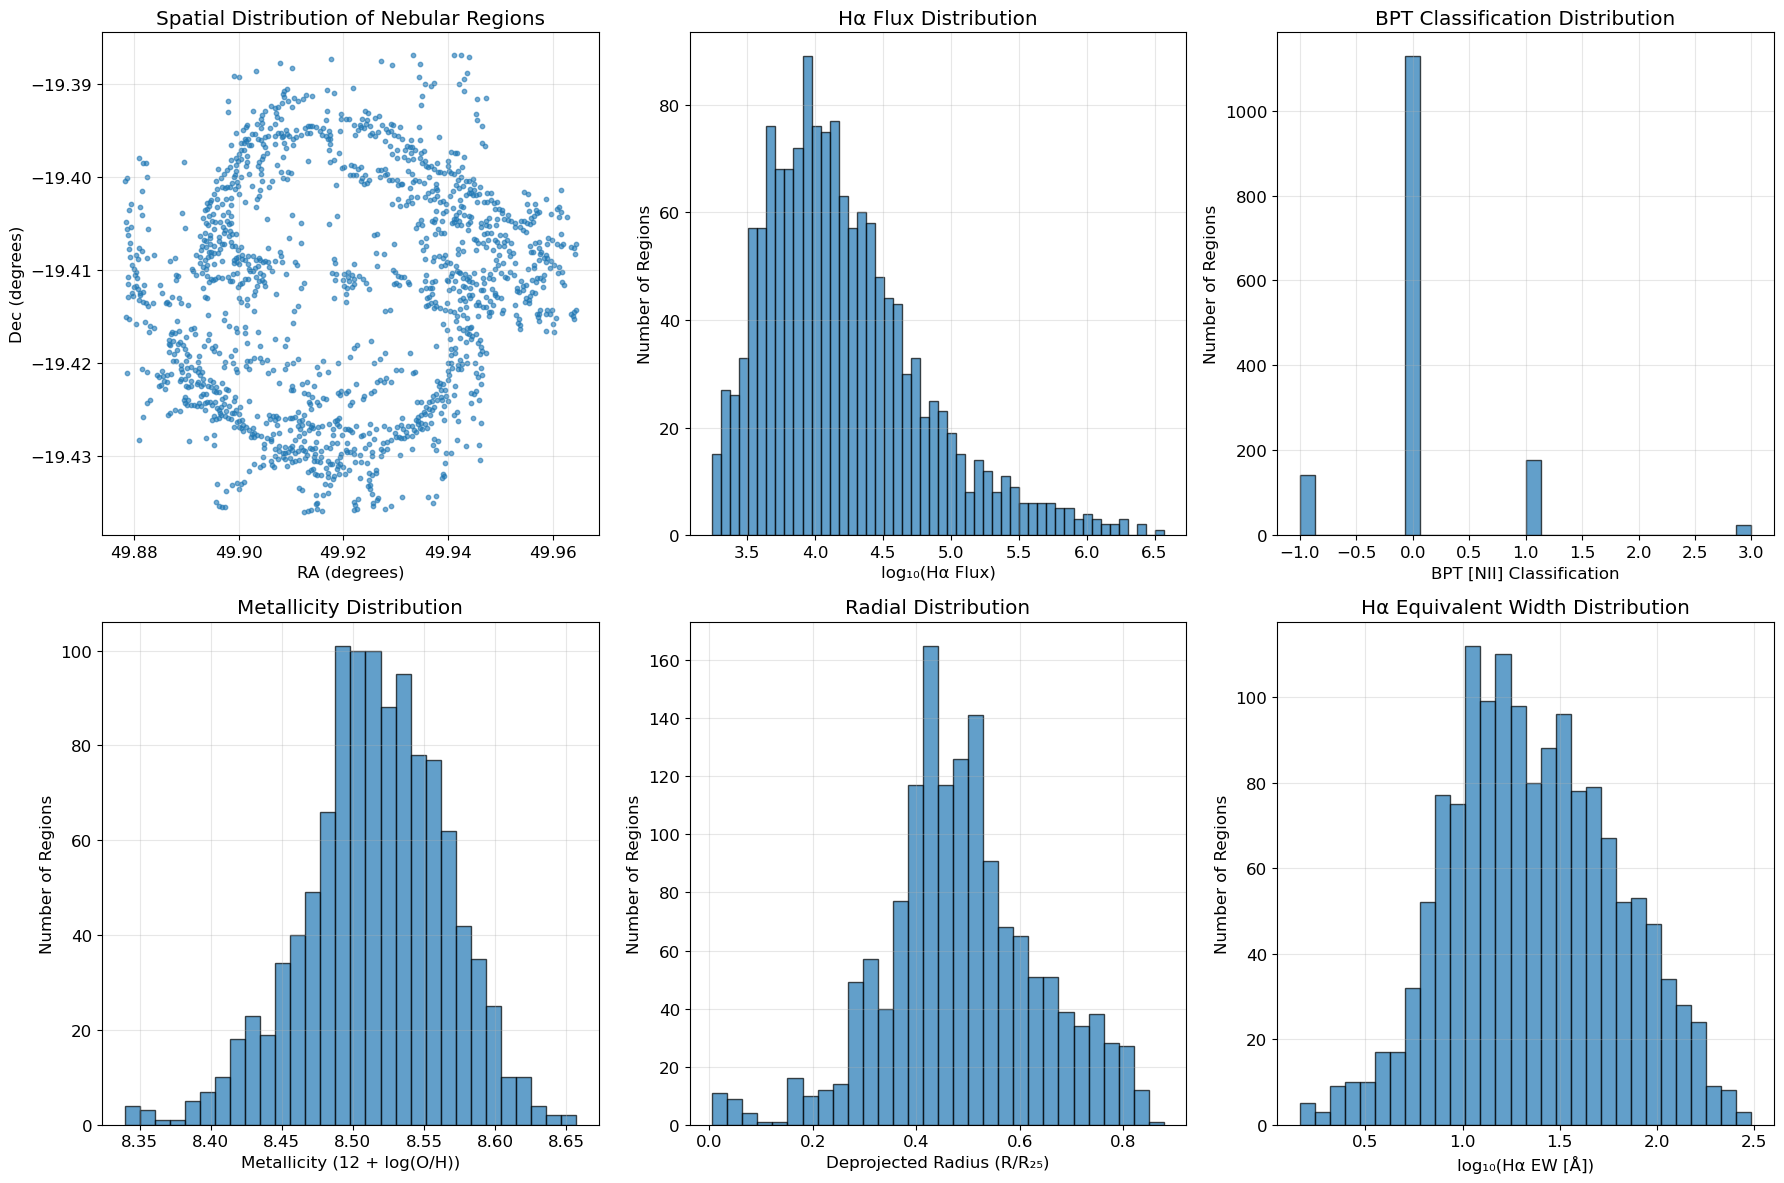

In [6]:
# Create some diagnostic plots for the catalog data
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# 1. Spatial distribution of regions
valid_coords = (catalog_data['RAJ2000'] > 0) & (catalog_data['DECJ2000'] != 0)
ra = catalog_data['RAJ2000'][valid_coords]
dec = catalog_data['DECJ2000'][valid_coords]

axes[0].scatter(ra, dec, alpha=0.6, s=10)
axes[0].set_xlabel('RA (degrees)')
axes[0].set_ylabel('Dec (degrees)')
axes[0].set_title('Spatial Distribution of Nebular Regions')
axes[0].grid(True, alpha=0.3)

# 2. Hα flux distribution
ha_flux = catalog_data['HA6562_FLUX']
valid_ha = ha_flux[ha_flux > 0]
if len(valid_ha) > 0:
    axes[1].hist(np.log10(valid_ha), bins=50, alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('log₁₀(Hα Flux)')
    axes[1].set_ylabel('Number of Regions')
    axes[1].set_title('Hα Flux Distribution')
    axes[1].grid(True, alpha=0.3)

# 3. BPT diagram (if available)
if 'BPT_NII' in catalog_data.dtype.names:
    bpt_nii = catalog_data['BPT_NII']
    valid_bpt = (bpt_nii > -90) & (bpt_nii < 90)  # Remove invalid values
    
    if np.any(valid_bpt):
        axes[2].hist(bpt_nii[valid_bpt], bins=30, alpha=0.7, edgecolor='black')
        axes[2].set_xlabel('BPT [NII] Classification')
        axes[2].set_ylabel('Number of Regions')
        axes[2].set_title('BPT Classification Distribution')
        axes[2].grid(True, alpha=0.3)

# 4. Metallicity distribution
if 'MET_SCAL' in catalog_data.dtype.names:
    metallicity = catalog_data['MET_SCAL']
    valid_met = (metallicity > 0) & (metallicity < 20)  # Reasonable metallicity range
    
    if np.any(valid_met):
        axes[3].hist(metallicity[valid_met], bins=30, alpha=0.7, edgecolor='black')
        axes[3].set_xlabel('Metallicity (12 + log(O/H))')
        axes[3].set_ylabel('Number of Regions')
        axes[3].set_title('Metallicity Distribution')
        axes[3].grid(True, alpha=0.3)

# 5. Radial distribution
if 'DEPROJ_R_R25' in catalog_data.dtype.names:
    radial_pos = catalog_data['DEPROJ_R_R25']
    valid_rad = (radial_pos > 0) & (radial_pos < 5)  # Reasonable radial range
    
    if np.any(valid_rad):
        axes[4].hist(radial_pos[valid_rad], bins=30, alpha=0.7, edgecolor='black')
        axes[4].set_xlabel('Deprojected Radius (R/R₂₅)')
        axes[4].set_ylabel('Number of Regions')
        axes[4].set_title('Radial Distribution')
        axes[4].grid(True, alpha=0.3)

# 6. Hα equivalent width distribution
if 'EW_HA6562_FIT' in catalog_data.dtype.names:
    ew_ha = catalog_data['EW_HA6562_FIT']
    valid_ew = (ew_ha > 0) & (ew_ha < 1000)  # Reasonable EW range
    
    if np.any(valid_ew):
        axes[5].hist(np.log10(ew_ha[valid_ew]), bins=30, alpha=0.7, edgecolor='black')
        axes[5].set_xlabel('log₁₀(Hα EW [Å])')
        axes[5].set_ylabel('Number of Regions')
        axes[5].set_title('Hα Equivalent Width Distribution')
        axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Show a sample of the actual data
print("SAMPLE DATA FROM THE CATALOG")
print("="*80)

# Show first 5 entries with key columns
key_columns = ['SOURCE_ID', 'RAJ2000', 'DECJ2000', 'HA6562_FLUX', 'NII6583_FLUX', 
               'OIII5006_FLUX', 'MET_SCAL', 'BPT_NII']

print(f"{'Index':<6}", end='')
for col in key_columns:
    if col in catalog_data.dtype.names:
        if col == 'SOURCE_ID':
            print(f"{col:<12}", end='')
        else:
            print(f"{col:<12}", end='')
print()

print("-" * 100)

for i in range(min(10, len(catalog_data))):
    print(f"{i:<6}", end='')
    for col in key_columns:
        if col in catalog_data.dtype.names:
            value = catalog_data[col][i]
            if col == 'SOURCE_ID':
                # Decode bytes to string
                print(f"{value.decode('utf-8') if hasattr(value, 'decode') else value:<12}", end='')
            elif isinstance(value, (int, float)):
                if abs(value) > 1000 or (abs(value) < 0.01 and value != 0):
                    print(f"{value:<12.2e}", end='')
                else:
                    print(f"{value:<12.3f}", end='')
            else:
                print(f"{str(value):<12}", end='')
    print()

print(f"\n... and {len(catalog_data)-10} more entries")

# Summary statistics
print(f"\nSUMMARY STATISTICS")
print("="*50)
print(f"Galaxy: {gal_name}")  # Use the already decoded variable
print(f"Total nebular regions: {len(catalog_data)}")

# Count valid detections for key lines
valid_ha = np.sum(catalog_data['HA6562_FLUX'] > 0)
valid_nii = np.sum(catalog_data['NII6583_FLUX'] > 0)
valid_oiii = np.sum(catalog_data['OIII5006_FLUX'] > 0)

print(f"Hα detections: {valid_ha} ({100*valid_ha/len(catalog_data):.1f}%)")
print(f"[NII] detections: {valid_nii} ({100*valid_nii/len(catalog_data):.1f}%)")
print(f"[OIII] detections: {valid_oiii} ({100*valid_oiii/len(catalog_data):.1f}%)")

if 'MET_SCAL' in catalog_data.dtype.names:
    valid_met = np.sum((catalog_data['MET_SCAL'] > 0) & (catalog_data['MET_SCAL'] < 20))
    print(f"Metallicity measurements: {valid_met} ({100*valid_met/len(catalog_data):.1f}%)")

SAMPLE DATA FROM THE CATALOG
Index SOURCE_ID   RAJ2000     DECJ2000    HA6562_FLUX NII6583_FLUXOIII5006_FLUXMET_SCAL    BPT_NII     
----------------------------------------------------------------------------------------------------
0     NGC1300_0   49.913      -19.411     8.59e+03    4.74e+03    3.20e+03    nan         1.000       
1     NGC1300_1   49.904      -19.426     8.20e+03    3.20e+03    1.15e+03    8.577       0.000       
2     NGC1300_2   49.925      -19.430     7.87e+04    2.39e+04    6.81e+03    8.590       0.000       
3     NGC1300_3   49.959      -19.404     8.65e+03    2.91e+03    699.137     8.544       0.000       
4     NGC1300_4   49.919      -19.395     1.14e+04    5.17e+03    748.569     8.648       0.000       
5     NGC1300_5   49.887      -19.425     9.76e+04    2.23e+04    3.33e+04    8.477       0.000       
6     NGC1300_6   49.943      -19.429     9.41e+03    3.11e+03    1.91e+03    8.533       0.000       
7     NGC1300_7   49.898      -19.393     7.7

In [8]:
# Create visualizations based on data type
# Find the primary data HDU (usually the first one with data)
primary_data_hdu = None
for i, hdu in enumerate(hdul):
    if hasattr(hdu, 'data') and hdu.data is not None:
        primary_data_hdu = hdu
        primary_data_idx = i
        break

if primary_data_hdu is not None:
    data = primary_data_hdu.data
    
    print(f"Creating visualizations for HDU {primary_data_idx} ({primary_data_hdu.name})")
    
    # Check if this is a structured array (catalog/table)
    if data.dtype.names is not None:
        print("This is a catalog/table - visualizations already created in previous cells!")
        print("The catalog data has been properly visualized with:")
        print("  - Spatial distribution plot")
        print("  - Emission line flux distributions")
        print("  - BPT classification histogram")
        print("  - Metallicity distribution")
        print("  - Radial distribution") 
        print("  - Equivalent width distribution")
        print("\nFor additional custom plots, access individual columns like:")
        print("  data['HA6562_FLUX'] for Hα fluxes")
        print("  data['MET_SCAL'] for metallicity")
        print("  data['RAJ2000'], data['DECJ2000'] for coordinates")
        
    elif len(data.shape) == 2:
        # 2D image
        plt.figure(figsize=(12, 10))
        
        # Remove NaN values for display
        plot_data = np.copy(data)
        plot_data[~np.isfinite(plot_data)] = np.nan
        
        # Use percentile scaling for better visualization
        vmin, vmax = np.nanpercentile(plot_data, [1, 99])
        
        plt.imshow(plot_data, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
        plt.colorbar(label='Flux')
        plt.title(f'PHANGS-MUSE Data - HDU {primary_data_idx}')
        plt.xlabel('X pixel')
        plt.ylabel('Y pixel')
        plt.show()
        
    elif len(data.shape) == 3:
        # 3D data cube - show a few slices
        n_slices_to_show = min(4, data.shape[0])
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()
        
        # Select slices evenly distributed through the cube
        slice_indices = np.linspace(0, data.shape[0]-1, n_slices_to_show, dtype=int)
        
        for i, slice_idx in enumerate(slice_indices):
            if i < len(axes):
                slice_data = data[slice_idx, :, :]
                slice_data[~np.isfinite(slice_data)] = np.nan
                
                if np.any(np.isfinite(slice_data)):
                    vmin, vmax = np.nanpercentile(slice_data, [1, 99])
                    im = axes[i].imshow(slice_data, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
                    axes[i].set_title(f'Slice {slice_idx}')
                    axes[i].set_xlabel('X pixel')
                    axes[i].set_ylabel('Y pixel')
                    plt.colorbar(im, ax=axes[i])
                else:
                    axes[i].text(0.5, 0.5, 'No finite data', ha='center', va='center', 
                               transform=axes[i].transAxes)
                    axes[i].set_title(f'Slice {slice_idx} (no data)')
        
        plt.tight_layout()
        plt.suptitle('PHANGS-MUSE Data Cube - Selected Slices', y=1.02)
        plt.show()
        
    elif len(data.shape) == 1 and data.dtype.names is None:
        # 1D spectrum (only if it's not a structured array)
        plt.figure(figsize=(12, 6))
        plt.plot(data)
        plt.title('PHANGS-MUSE 1D Data')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.grid(True, alpha=0.3)
        plt.show()
        
else:
    print("No data HDUs found in the FITS file")

Creating visualizations for HDU 1 (PHASE3CATALOG)
This is a catalog/table - visualizations already created in previous cells!
The catalog data has been properly visualized with:
  - Spatial distribution plot
  - Emission line flux distributions
  - BPT classification histogram
  - Metallicity distribution
  - Radial distribution
  - Equivalent width distribution

For additional custom plots, access individual columns like:
  data['HA6562_FLUX'] for Hα fluxes
  data['MET_SCAL'] for metallicity
  data['RAJ2000'], data['DECJ2000'] for coordinates


In [9]:
# Check for World Coordinate System (WCS) information
try:
    from astropy.wcs import WCS
    
    for i, hdu in enumerate(hdul):
        if hasattr(hdu, 'header'):
            try:
                w = WCS(hdu.header)
                print(f"\nWCS information for HDU {i} ({hdu.name}):")
                print(f"  Number of axes: {w.naxis}")
                if w.naxis >= 2:
                    print(f"  Coordinate types: {w.axis_type_names}")
                    if hasattr(w, 'celestial'):
                        print(f"  Celestial coordinate system: {w.celestial}")
                print(f"  WCS object: {w}")
                
                # If there's data, try to get coordinate information
                if hasattr(hdu, 'data') and hdu.data is not None and w.naxis >= 2:
                    shape = hdu.data.shape
                    if len(shape) >= 2:
                        # Get corner coordinates
                        corners = [
                            [0, 0],
                            [0, shape[-1]-1],
                            [shape[-2]-1, 0],
                            [shape[-2]-1, shape[-1]-1]
                        ]
                        
                        print("  Corner coordinates (pixel -> world):")
                        for corner in corners:
                            try:
                                if len(shape) == 2:
                                    world_coords = w.pixel_to_world(corner[1], corner[0])
                                elif len(shape) == 3:
                                    world_coords = w.pixel_to_world(corner[1], corner[0], 0)
                                print(f"    Pixel {corner} -> {world_coords}")
                            except Exception as e:
                                print(f"    Pixel {corner} -> Error: {e}")
                                
            except Exception as e:
                print(f"Could not create WCS for HDU {i}: {e}")
                
except ImportError:
    print("WCS analysis requires astropy.wcs")


WCS information for HDU 0 (PRIMARY):
  Number of axes: 2
  Coordinate types: ['', '']
  Celestial coordinate system: WCS Keywords

Number of WCS axes: 0
CTYPE : 
CRVAL : 
CRPIX : 
CDELT : 
NAXIS : 0  0
  WCS object: WCS Keywords

Number of WCS axes: 2
CTYPE : '' '' 
CRVAL : 0.0 0.0 
CRPIX : 0.0 0.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 1.0 1.0 
NAXIS : 0  0

WCS information for HDU 1 (PHASE3CATALOG):
  Number of axes: 2
  Coordinate types: ['', '']
  Celestial coordinate system: WCS Keywords

Number of WCS axes: 0
CTYPE : 
CRVAL : 
CRPIX : 
CDELT : 
NAXIS : 
  WCS object: WCS Keywords

Number of WCS axes: 2
CTYPE : '' '' 
CRVAL : 0.0 0.0 
CRPIX : 0.0 0.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 1.0 1.0 
NAXIS : 603  1472


FITS file is still open, proceeding with Hα map creation...
Creating Hα map of NGC1330...
Number of regions with valid Hα detections: 1472
Hα flux range: 1.76e+03 to 3.70e+06


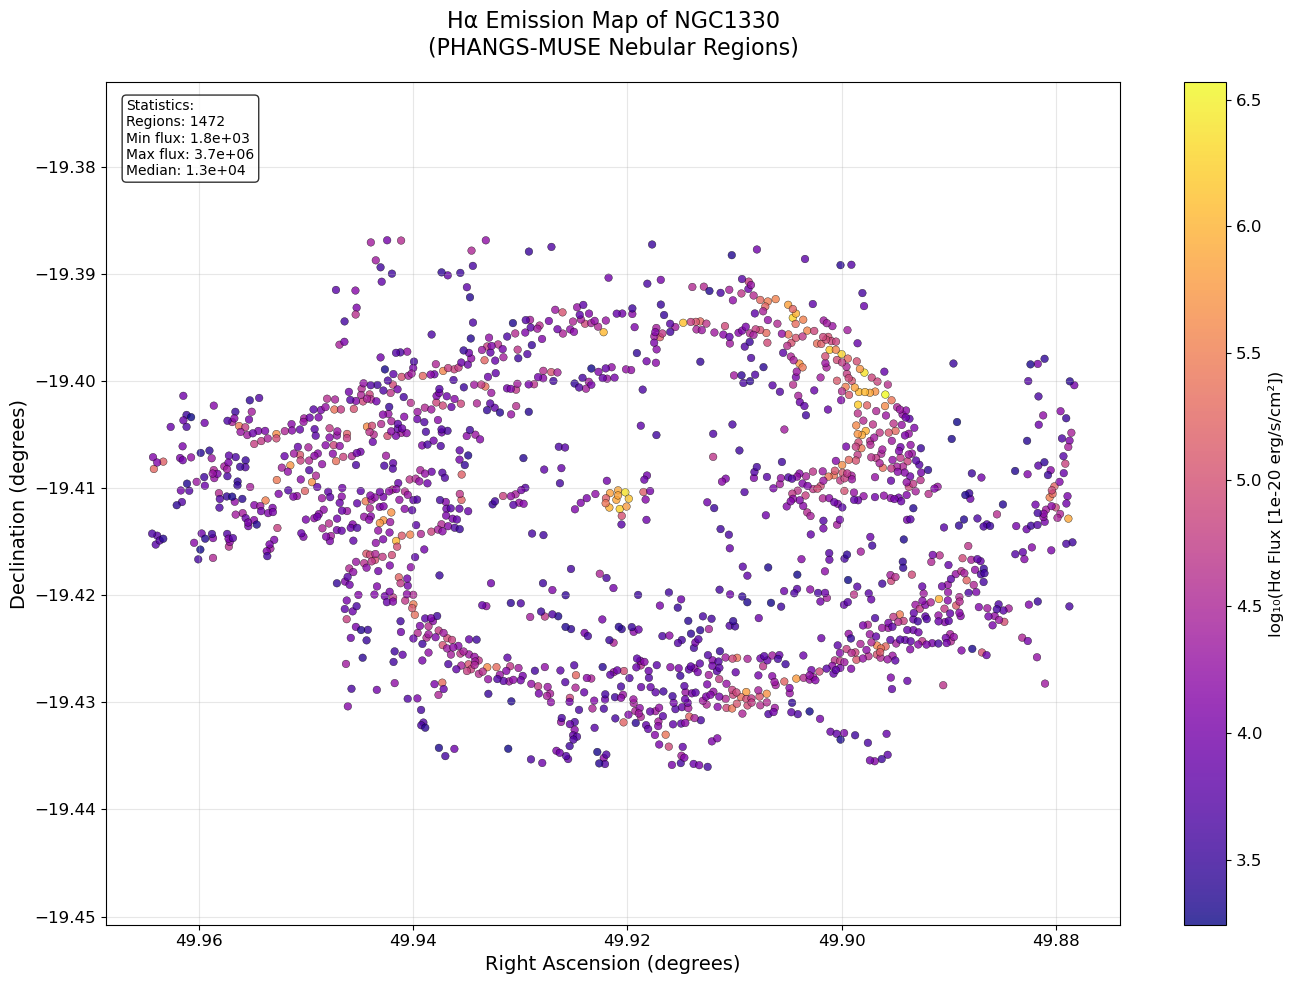

Hα map created successfully!
Note: FITS file remains open for further analysis.


In [10]:
# Create Hα map of NGC1330
# Re-open the FITS file if needed
try:
    # Check if hdul is still accessible
    test = len(hdul)
    print("FITS file is still open, proceeding with Hα map creation...")
except:
    print("Re-opening FITS file...")
    hdul = fits.open(fits_file)
    catalog_data = hdul[1].data

print("Creating Hα map of NGC1330...")

# Extract spatial coordinates and Hα flux
ra = catalog_data['RAJ2000']
dec = catalog_data['DECJ2000'] 
ha_flux = catalog_data['HA6562_FLUX']

# Filter for valid coordinates and positive Hα flux
valid_mask = (ra > 0) & (dec != 0) & (ha_flux > 0)
ra_valid = ra[valid_mask]
dec_valid = dec[valid_mask]
ha_flux_valid = ha_flux[valid_mask]

print(f"Number of regions with valid Hα detections: {len(ha_flux_valid)}")
print(f"Hα flux range: {np.min(ha_flux_valid):.2e} to {np.max(ha_flux_valid):.2e}")

# Create the Hα map
plt.figure(figsize=(14, 10))

# Use logarithmic scaling for better visualization
log_ha_flux = np.log10(ha_flux_valid)

# Create scatter plot with color-coded Hα flux
scatter = plt.scatter(ra_valid, dec_valid, c=log_ha_flux, 
                     s=30, alpha=0.8, cmap='plasma', edgecolors='black', linewidth=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, label='log₁₀(Hα Flux [1e-20 erg/s/cm²])')
cbar.ax.tick_params(labelsize=12)

# Format the plot
plt.xlabel('Right Ascension (degrees)', fontsize=14)
plt.ylabel('Declination (degrees)', fontsize=14)
plt.title('Hα Emission Map of NGC1330\n(PHANGS-MUSE Nebular Regions)', fontsize=16, pad=20)
plt.grid(True, alpha=0.3)

# Invert RA axis (astronomical convention)
plt.gca().invert_xaxis()

# Make axes equal aspect ratio
plt.axis('equal')

# Add statistics text box
stats_text = f"""Statistics:
Regions: {len(ha_flux_valid)}
Min flux: {np.min(ha_flux_valid):.1e}
Max flux: {np.max(ha_flux_valid):.1e}
Median: {np.median(ha_flux_valid):.1e}"""

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         fontsize=10)

plt.tight_layout()
plt.show()

print("Hα map created successfully!")
print("Note: FITS file remains open for further analysis.")

Creating enhanced Hα map with multiple visualizations...


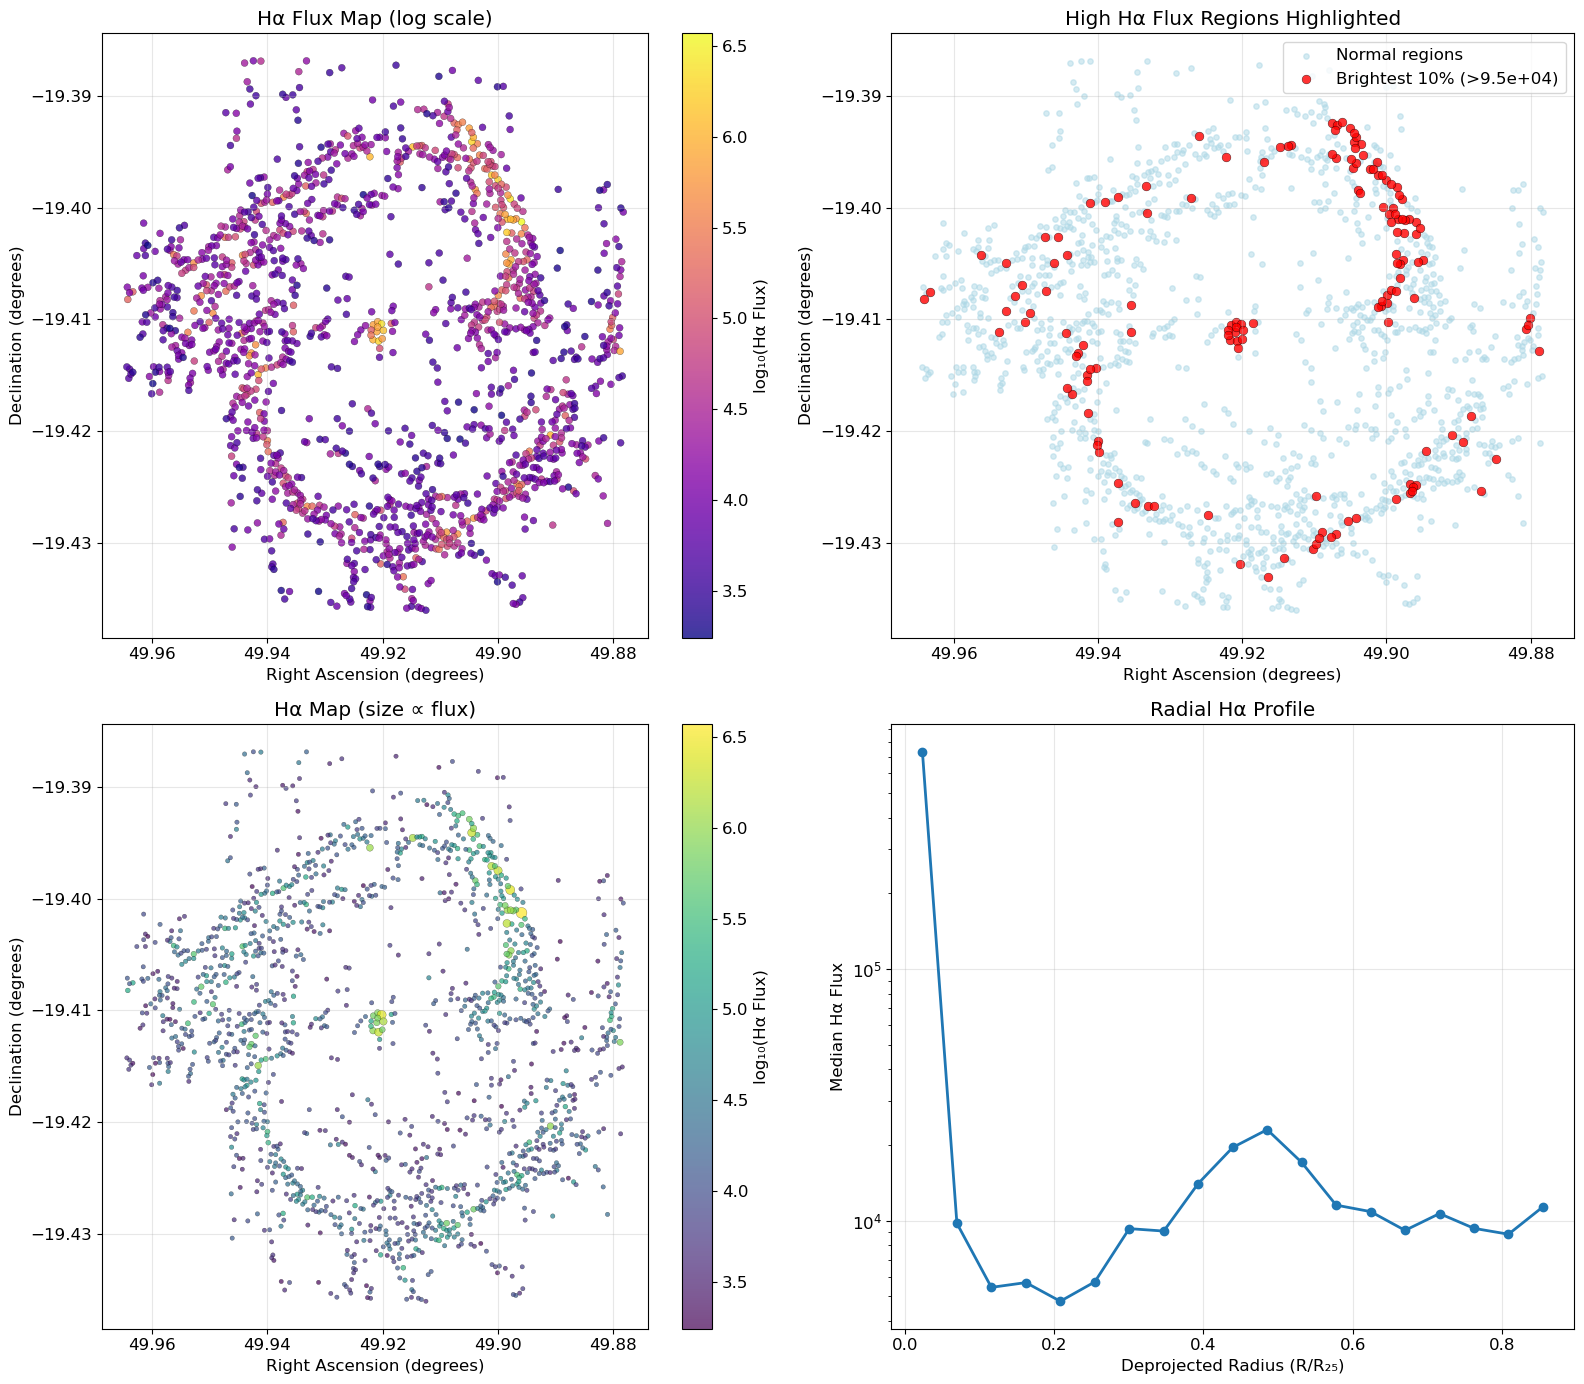


Detailed Hα Statistics for NGC1330:
Total HII regions detected: 1472
Flux range: 1.76e+03 - 3.70e+06 1e-20 erg/s/cm²
Median flux: 1.27e+04 1e-20 erg/s/cm²
Top 10% brightest regions have flux > 9.51e+04 1e-20 erg/s/cm²
Number of very bright regions (top 10%): 148

Spatial Coverage:
RA range: 49.8783° to 49.9644°
Dec range: -19.4360° to -19.3869°
Angular size: 0.0861° × 0.0491°


In [11]:
# Create enhanced Hα map with additional features
print("Creating enhanced Hα map with multiple visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Common data for all plots
ra_valid = ra[valid_mask]
dec_valid = dec[valid_mask]
ha_flux_valid = ha_flux[valid_mask]
log_ha_flux = np.log10(ha_flux_valid)

# Plot 1: Standard Hα flux map
scatter1 = axes[0,0].scatter(ra_valid, dec_valid, c=log_ha_flux, 
                            s=25, alpha=0.8, cmap='plasma', edgecolors='black', linewidth=0.2)
axes[0,0].set_xlabel('Right Ascension (degrees)')
axes[0,0].set_ylabel('Declination (degrees)')
axes[0,0].set_title('Hα Flux Map (log scale)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].invert_xaxis()
cbar1 = plt.colorbar(scatter1, ax=axes[0,0], label='log₁₀(Hα Flux)')

# Plot 2: High flux regions highlighted
high_flux_threshold = np.percentile(ha_flux_valid, 90)  # Top 10% brightest
high_flux_mask = ha_flux_valid >= high_flux_threshold

axes[0,1].scatter(ra_valid[~high_flux_mask], dec_valid[~high_flux_mask], 
                 c='lightblue', s=15, alpha=0.5, label='Normal regions')
axes[0,1].scatter(ra_valid[high_flux_mask], dec_valid[high_flux_mask], 
                 c='red', s=40, alpha=0.8, edgecolors='black', linewidth=0.3,
                 label=f'Brightest 10% (>{high_flux_threshold:.1e})')
axes[0,1].set_xlabel('Right Ascension (degrees)')
axes[0,1].set_ylabel('Declination (degrees)')
axes[0,1].set_title('High Hα Flux Regions Highlighted')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].invert_xaxis()
axes[0,1].legend()

# Plot 3: Hα flux size-coded
# Use flux to determine point sizes
sizes = 10 + 50 * (ha_flux_valid - np.min(ha_flux_valid)) / (np.max(ha_flux_valid) - np.min(ha_flux_valid))
scatter3 = axes[1,0].scatter(ra_valid, dec_valid, s=sizes, c=log_ha_flux,
                            alpha=0.7, cmap='viridis', edgecolors='black', linewidth=0.2)
axes[1,0].set_xlabel('Right Ascension (degrees)')
axes[1,0].set_ylabel('Declination (degrees)')
axes[1,0].set_title('Hα Map (size ∝ flux)')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].invert_xaxis()
cbar3 = plt.colorbar(scatter3, ax=axes[1,0], label='log₁₀(Hα Flux)')

# Plot 4: Radial profile if available
if 'DEPROJ_R_R25' in catalog_data.dtype.names:
    radial_dist = catalog_data['DEPROJ_R_R25'][valid_mask]
    
    # Create radial bins
    r_bins = np.linspace(0, np.max(radial_dist), 20)
    r_centers = (r_bins[1:] + r_bins[:-1]) / 2
    
    # Calculate median flux in each radial bin
    median_flux_bins = []
    for i in range(len(r_bins)-1):
        mask_bin = (radial_dist >= r_bins[i]) & (radial_dist < r_bins[i+1])
        if np.sum(mask_bin) > 0:
            median_flux_bins.append(np.median(ha_flux_valid[mask_bin]))
        else:
            median_flux_bins.append(np.nan)
    
    axes[1,1].plot(r_centers, median_flux_bins, 'o-', linewidth=2, markersize=6)
    axes[1,1].set_xlabel('Deprojected Radius (R/R₂₅)')
    axes[1,1].set_ylabel('Median Hα Flux')
    axes[1,1].set_title('Radial Hα Profile')
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].set_yscale('log')
else:
    # If no radial data, show flux histogram
    axes[1,1].hist(log_ha_flux, bins=30, alpha=0.7, edgecolor='black')
    axes[1,1].set_xlabel('log₁₀(Hα Flux)')
    axes[1,1].set_ylabel('Number of Regions')
    axes[1,1].set_title('Hα Flux Distribution')
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some interesting statistics
print(f"\nDetailed Hα Statistics for NGC1330:")
print(f"{'='*50}")
print(f"Total HII regions detected: {len(ha_flux_valid)}")
print(f"Flux range: {np.min(ha_flux_valid):.2e} - {np.max(ha_flux_valid):.2e} 1e-20 erg/s/cm²")
print(f"Median flux: {np.median(ha_flux_valid):.2e} 1e-20 erg/s/cm²")
print(f"Top 10% brightest regions have flux > {high_flux_threshold:.2e} 1e-20 erg/s/cm²")
print(f"Number of very bright regions (top 10%): {np.sum(high_flux_mask)}")

# Spatial extent
print(f"\nSpatial Coverage:")
print(f"RA range: {np.min(ra_valid):.4f}° to {np.max(ra_valid):.4f}°")
print(f"Dec range: {np.min(dec_valid):.4f}° to {np.max(dec_valid):.4f}°")
print(f"Angular size: {np.max(ra_valid)-np.min(ra_valid):.4f}° × {np.max(dec_valid)-np.min(dec_valid):.4f}°")

In [12]:
# Check for stellar mass surface density and create rMZR or metallicity-Hα relation
print("Checking available columns for stellar mass and using corrected fluxes...")
print("="*60)

# Look for stellar mass-related columns
mass_columns = [col for col in catalog_data.dtype.names if 'MASS' in col.upper() or 'STELLAR' in col.upper()]
print(f"Stellar mass-related columns found: {mass_columns}")

# Look for corrected flux columns
corr_flux_columns = [col for col in catalog_data.dtype.names if 'FLUX_CORR' in col]
print(f"Corrected flux columns found: {corr_flux_columns}")

# Use corrected fluxes for analysis
ha_flux_corr = catalog_data['HA6562_FLUX_CORR']
metallicity = catalog_data['MET_SCAL']

# Create valid data mask using corrected fluxes
valid_mask_corr = (catalog_data['RAJ2000'] > 0) & (catalog_data['DECJ2000'] != 0) & \
                  (ha_flux_corr > 0) & (metallicity > 0) & (metallicity < 20) & \
                  np.isfinite(metallicity)

print(f"\nData quality with corrected fluxes:")
print(f"Total regions: {len(catalog_data)}")
print(f"Valid regions for analysis: {np.sum(valid_mask_corr)}")

# Extract valid data
ra_valid = catalog_data['RAJ2000'][valid_mask_corr]
dec_valid = catalog_data['DECJ2000'][valid_mask_corr]
ha_flux_valid = ha_flux_corr[valid_mask_corr]
met_valid = metallicity[valid_mask_corr]

if len(mass_columns) > 0:
    print(f"\nFound stellar mass data! Will create rMZR using: {mass_columns[0]}")
    # Try to use the first mass column found
    mass_data = catalog_data[mass_columns[0]][valid_mask_corr]
    has_mass_data = True
else:
    print(f"\nNo stellar mass data found. Will create metallicity-Hα relation instead.")
    has_mass_data = False

Checking available columns for stellar mass and using corrected fluxes...
Stellar mass-related columns found: []
Corrected flux columns found: ['HB4861_FLUX_CORR', 'OIII5006_FLUX_CORR', 'HA6562_FLUX_CORR', 'NII6583_FLUX_CORR', 'SII6716_FLUX_CORR', 'SII6730_FLUX_CORR', 'SIII9068_FLUX_CORR', 'OI6300_FLUX_CORR', 'HB4861_FLUX_CORR_ERR', 'OIII5006_FLUX_CORR_ERR', 'HA6562_FLUX_CORR_ERR', 'NII6583_FLUX_CORR_ERR', 'SII6716_FLUX_CORR_ERR', 'SII6730_FLUX_CORR_ERR', 'SIII9068_FLUX_CORR_ERR', 'OI6300_FLUX_CORR_ERR']

Data quality with corrected fluxes:
Total regions: 1472
Valid regions for analysis: 1111

No stellar mass data found. Will create metallicity-Hα relation instead.


Creating Metallicity-Hα Relation Analysis...


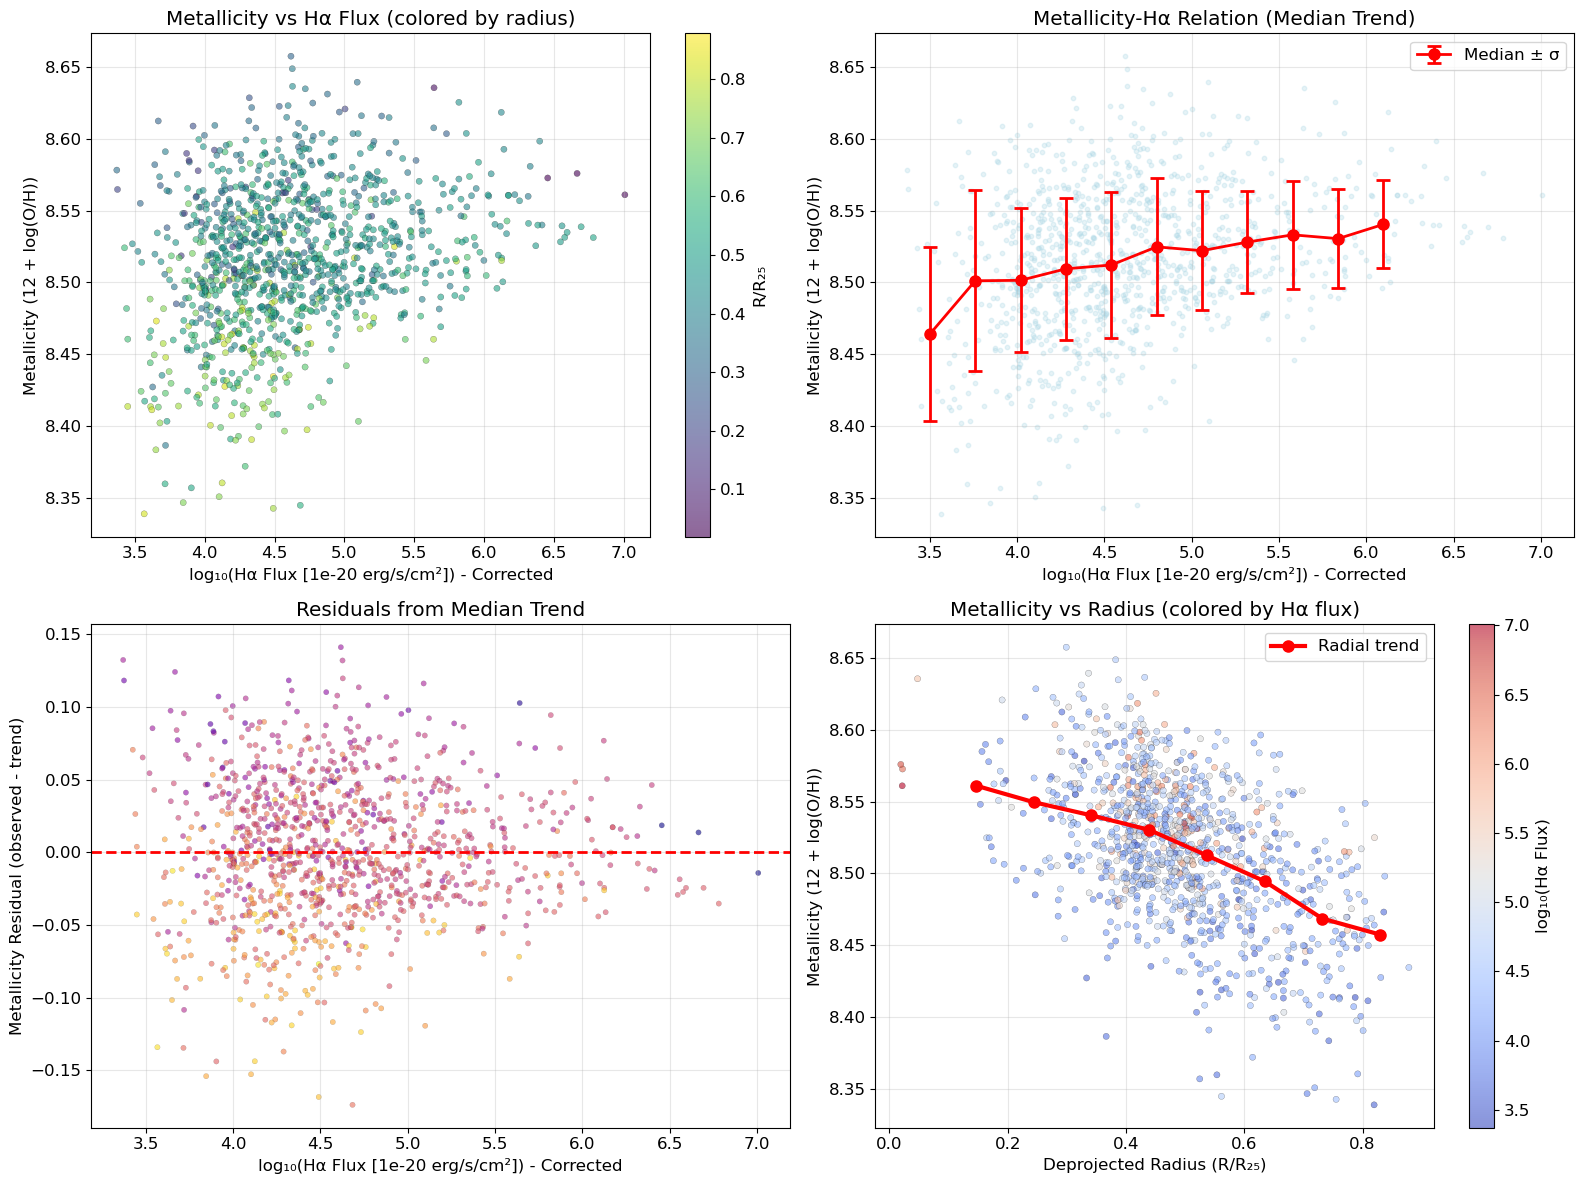


Metallicity-Hα Relation Statistics:
Valid regions for analysis: 1111
Metallicity range: 8.339 - 8.657
Mean metallicity: 8.516 ± 0.050
Hα flux range (corrected): 2.35e+03 - 1.02e+07

Correlations:
Pearson correlation: r = 0.272, p = 3.15e-20
Spearman correlation: ρ = 0.257, p = 3.57e-18
→ Positive correlation: Higher Hα flux regions tend to have higher metallicity


In [13]:
# Create metallicity-Hα relation using corrected fluxes
print("Creating Metallicity-Hα Relation Analysis...")
print("="*50)

# Create figure with multiple panels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Metallicity vs log(Hα flux) scatter plot
log_ha_corr = np.log10(ha_flux_valid)

scatter1 = axes[0,0].scatter(log_ha_corr, met_valid, alpha=0.6, s=20, 
                            c=catalog_data['DEPROJ_R_R25'][valid_mask_corr], 
                            cmap='viridis', edgecolors='black', linewidth=0.2)
axes[0,0].set_xlabel('log₁₀(Hα Flux [1e-20 erg/s/cm²]) - Corrected')
axes[0,0].set_ylabel('Metallicity (12 + log(O/H))')
axes[0,0].set_title('Metallicity vs Hα Flux (colored by radius)')
axes[0,0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0,0], label='R/R₂₅')

# Panel 2: Binned median trend
# Create bins for Hα flux
ha_bins = np.linspace(np.min(log_ha_corr), np.max(log_ha_corr), 15)
ha_centers = (ha_bins[1:] + ha_bins[:-1]) / 2
met_medians = []
met_stds = []
n_points = []

for i in range(len(ha_bins)-1):
    mask_bin = (log_ha_corr >= ha_bins[i]) & (log_ha_corr < ha_bins[i+1])
    if np.sum(mask_bin) >= 10:  # At least 10 points per bin
        met_medians.append(np.median(met_valid[mask_bin]))
        met_stds.append(np.std(met_valid[mask_bin]))
        n_points.append(np.sum(mask_bin))
    else:
        met_medians.append(np.nan)
        met_stds.append(np.nan)
        n_points.append(0)

# Plot binned trend
valid_bins = ~np.isnan(met_medians)
axes[0,1].errorbar(ha_centers[valid_bins], np.array(met_medians)[valid_bins], 
                   yerr=np.array(met_stds)[valid_bins], 
                   fmt='o-', color='red', linewidth=2, markersize=8, 
                   capsize=5, capthick=2, label='Median ± σ')

# Add scatter plot in background
axes[0,1].scatter(log_ha_corr, met_valid, alpha=0.3, s=10, color='lightblue')
axes[0,1].set_xlabel('log₁₀(Hα Flux [1e-20 erg/s/cm²]) - Corrected')
axes[0,1].set_ylabel('Metallicity (12 + log(O/H))')
axes[0,1].set_title('Metallicity-Hα Relation (Median Trend)')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# Panel 3: Residuals from median trend
# Interpolate median trend for each point
from scipy.interpolate import interp1d
if np.sum(valid_bins) > 3:
    # Create interpolation function
    interp_func = interp1d(ha_centers[valid_bins], np.array(met_medians)[valid_bins], 
                          kind='linear', bounds_error=False, fill_value='extrapolate')
    met_trend = interp_func(log_ha_corr)
    residuals = met_valid - met_trend
    
    axes[1,0].scatter(log_ha_corr, residuals, alpha=0.6, s=15, 
                     c=catalog_data['DEPROJ_R_R25'][valid_mask_corr], 
                     cmap='plasma', edgecolors='black', linewidth=0.1)
    axes[1,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1,0].set_xlabel('log₁₀(Hα Flux [1e-20 erg/s/cm²]) - Corrected')
    axes[1,0].set_ylabel('Metallicity Residual (observed - trend)')
    axes[1,0].set_title('Residuals from Median Trend')
    axes[1,0].grid(True, alpha=0.3)

# Panel 4: Metallicity vs radial position
radial_pos = catalog_data['DEPROJ_R_R25'][valid_mask_corr]
valid_radial = (radial_pos > 0) & (radial_pos < 2)

if np.any(valid_radial):
    scatter4 = axes[1,1].scatter(radial_pos[valid_radial], met_valid[valid_radial], 
                                alpha=0.6, s=20, c=log_ha_corr[valid_radial], 
                                cmap='coolwarm', edgecolors='black', linewidth=0.2)
    
    # Add radial trend
    r_bins = np.linspace(0, np.max(radial_pos[valid_radial]), 10)
    r_centers = (r_bins[1:] + r_bins[:-1]) / 2
    met_radial = []
    
    for i in range(len(r_bins)-1):
        mask_r = (radial_pos >= r_bins[i]) & (radial_pos < r_bins[i+1]) & valid_radial
        if np.sum(mask_r) >= 5:
            met_radial.append(np.median(met_valid[mask_r]))
        else:
            met_radial.append(np.nan)
    
    valid_r = ~np.isnan(met_radial)
    if np.any(valid_r):
        axes[1,1].plot(r_centers[valid_r], np.array(met_radial)[valid_r], 
                      'ro-', linewidth=3, markersize=8, label='Radial trend')
    
    axes[1,1].set_xlabel('Deprojected Radius (R/R₂₅)')
    axes[1,1].set_ylabel('Metallicity (12 + log(O/H))')
    axes[1,1].set_title('Metallicity vs Radius (colored by Hα flux)')
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].legend()
    cbar4 = plt.colorbar(scatter4, ax=axes[1,1], label='log₁₀(Hα Flux)')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nMetallicity-Hα Relation Statistics:")
print(f"{'='*40}")
print(f"Valid regions for analysis: {len(met_valid)}")
print(f"Metallicity range: {np.min(met_valid):.3f} - {np.max(met_valid):.3f}")
print(f"Mean metallicity: {np.mean(met_valid):.3f} ± {np.std(met_valid):.3f}")
print(f"Hα flux range (corrected): {np.min(ha_flux_valid):.2e} - {np.max(ha_flux_valid):.2e}")

# Calculate correlation coefficient
from scipy.stats import pearsonr, spearmanr
pearson_r, pearson_p = pearsonr(log_ha_corr, met_valid)
spearman_r, spearman_p = spearmanr(log_ha_corr, met_valid)

print(f"\nCorrelations:")
print(f"Pearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.2e}")
print(f"Spearman correlation: ρ = {spearman_r:.3f}, p = {spearman_p:.2e}")

if abs(pearson_r) > 0.1:
    if pearson_r > 0:
        print("→ Positive correlation: Higher Hα flux regions tend to have higher metallicity")
    else:
        print("→ Negative correlation: Higher Hα flux regions tend to have lower metallicity")
else:
    print("→ Weak or no significant correlation detected")

Creating updated Hα map using corrected fluxes...


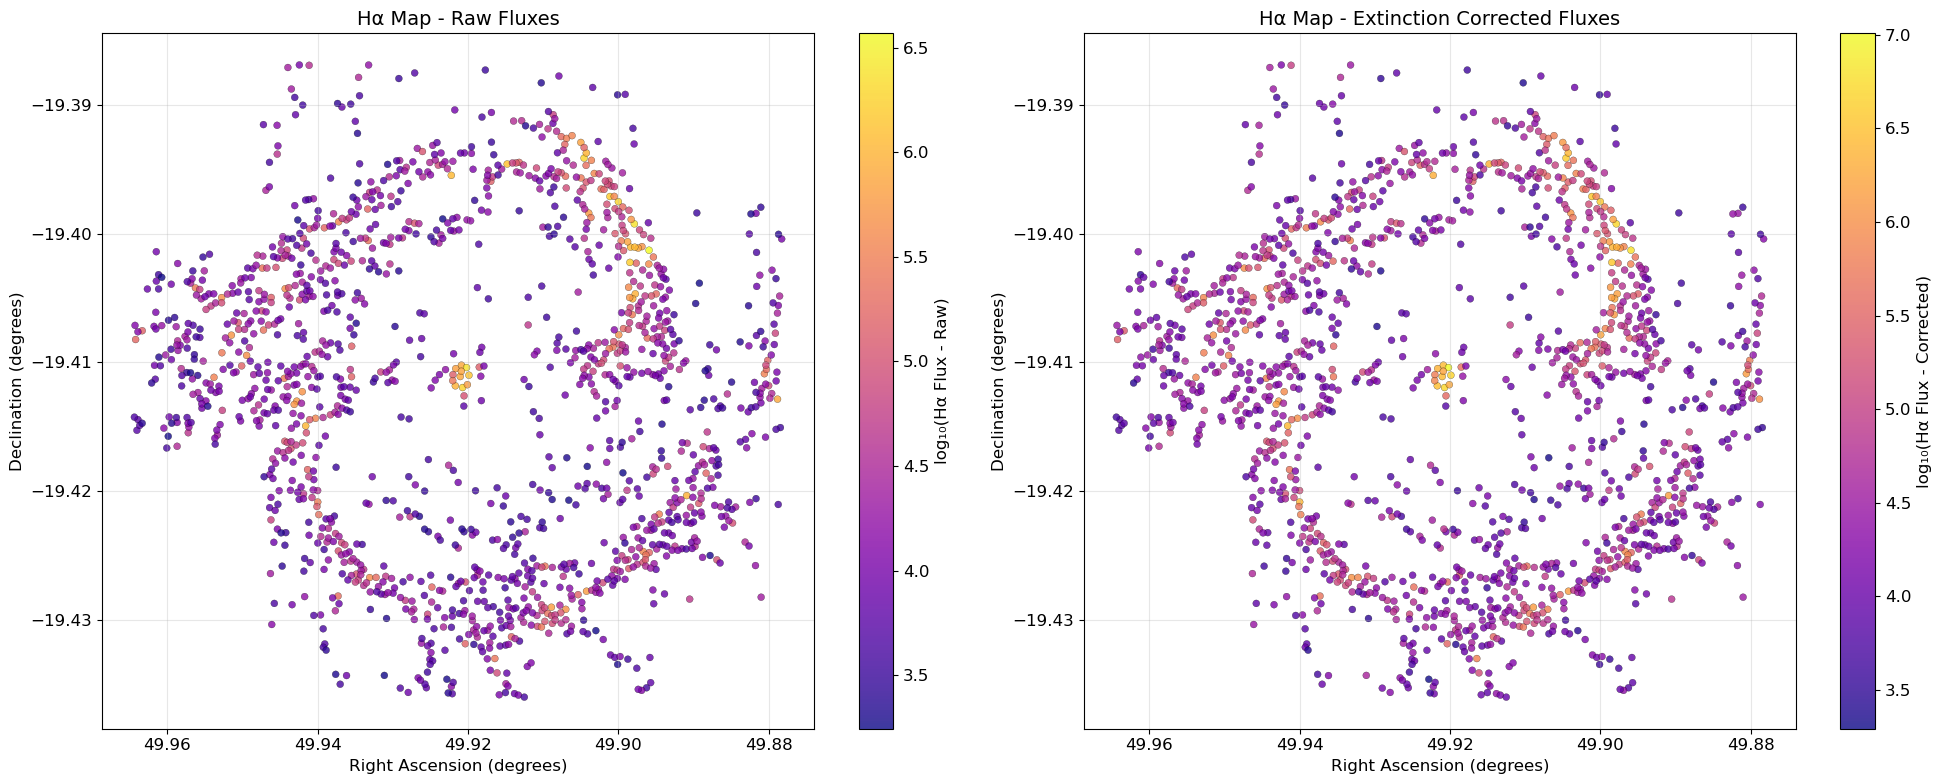


Comparison of Raw vs Corrected Hα Fluxes:
Raw flux - Valid regions: 1472
Raw flux - Range: 1.76e+03 to 3.70e+06
Raw flux - Median: 1.27e+04

Corrected flux - Valid regions: 1472
Corrected flux - Range: 1.97e+03 to 1.02e+07
Corrected flux - Median: 2.41e+04

Median extinction correction factor: 1.87
This corresponds to A(Hα) ≈ 0.68 mag

FITS file remains open for further analysis.


In [14]:
# Update the Hα map to use corrected fluxes
print("Creating updated Hα map using corrected fluxes...")

# Create comparison between raw and corrected fluxes
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left panel: Raw fluxes (from earlier)
ha_flux_raw = catalog_data['HA6562_FLUX']
valid_mask_raw = (catalog_data['RAJ2000'] > 0) & (catalog_data['DECJ2000'] != 0) & (ha_flux_raw > 0)
ra_raw = catalog_data['RAJ2000'][valid_mask_raw]
dec_raw = catalog_data['DECJ2000'][valid_mask_raw]
ha_flux_raw_valid = ha_flux_raw[valid_mask_raw]
log_ha_raw = np.log10(ha_flux_raw_valid)

scatter_raw = axes[0].scatter(ra_raw, dec_raw, c=log_ha_raw, 
                             s=25, alpha=0.8, cmap='plasma', edgecolors='black', linewidth=0.2)
axes[0].set_xlabel('Right Ascension (degrees)', fontsize=12)
axes[0].set_ylabel('Declination (degrees)', fontsize=12)
axes[0].set_title('Hα Map - Raw Fluxes', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()
cbar_raw = plt.colorbar(scatter_raw, ax=axes[0], label='log₁₀(Hα Flux - Raw)')

# Right panel: Corrected fluxes
ha_flux_corr = catalog_data['HA6562_FLUX_CORR']
valid_mask_corr_map = (catalog_data['RAJ2000'] > 0) & (catalog_data['DECJ2000'] != 0) & (ha_flux_corr > 0)
ra_corr = catalog_data['RAJ2000'][valid_mask_corr_map]
dec_corr = catalog_data['DECJ2000'][valid_mask_corr_map]
ha_flux_corr_valid = ha_flux_corr[valid_mask_corr_map]
log_ha_corr_map = np.log10(ha_flux_corr_valid)

scatter_corr = axes[1].scatter(ra_corr, dec_corr, c=log_ha_corr_map, 
                              s=25, alpha=0.8, cmap='plasma', edgecolors='black', linewidth=0.2)
axes[1].set_xlabel('Right Ascension (degrees)', fontsize=12)
axes[1].set_ylabel('Declination (degrees)', fontsize=12)
axes[1].set_title('Hα Map - Extinction Corrected Fluxes', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()
cbar_corr = plt.colorbar(scatter_corr, ax=axes[1], label='log₁₀(Hα Flux - Corrected)')

plt.tight_layout()
plt.show()

# Print comparison statistics
print(f"\nComparison of Raw vs Corrected Hα Fluxes:")
print(f"{'='*50}")
print(f"Raw flux - Valid regions: {len(ha_flux_raw_valid)}")
print(f"Raw flux - Range: {np.min(ha_flux_raw_valid):.2e} to {np.max(ha_flux_raw_valid):.2e}")
print(f"Raw flux - Median: {np.median(ha_flux_raw_valid):.2e}")

print(f"\nCorrected flux - Valid regions: {len(ha_flux_corr_valid)}")
print(f"Corrected flux - Range: {np.min(ha_flux_corr_valid):.2e} to {np.max(ha_flux_corr_valid):.2e}")
print(f"Corrected flux - Median: {np.median(ha_flux_corr_valid):.2e}")

# Calculate median extinction correction
correction_factor = np.median(ha_flux_corr_valid / ha_flux_raw_valid)
print(f"\nMedian extinction correction factor: {correction_factor:.2f}")
print(f"This corresponds to A(Hα) ≈ {-2.5 * np.log10(1/correction_factor):.2f} mag")

print(f"\nFITS file remains open for further analysis.")

In [15]:
# Calculate O3N2-M13 metallicity for HII regions only
print("Calculating O3N2-M13 metallicity using corrected fluxes...")
print("="*60)

def calculate_o3n2_m13_metallicity(oiii5006_flux, hb4861_flux, nii6583_flux, ha6562_flux):
    """
    Calculate [O/H] using O3N2-M13 (Marino et al. 2013) calibration
    O3N2 = log10([OIII]5007/Hβ) - log10([NII]6583/Hα)
    [O/H] = 8.533 - 0.214 * O3N2
    """
    # Use basic finite checks on emission lines
    good_mask = (np.isfinite(oiii5006_flux) & np.isfinite(hb4861_flux) & 
                 np.isfinite(nii6583_flux) & np.isfinite(ha6562_flux) &
                 (oiii5006_flux > 0) & (hb4861_flux > 0) & 
                 (nii6583_flux > 0) & (ha6562_flux > 0))
    
    # Calculate O3N2 ratio and then [O/H] metallicity using M13 calibration
    oh_o3n2_m13 = np.full_like(oiii5006_flux, np.nan)
    
    # O3N2 = log([OIII]/Hβ) - log([NII]/Hα)
    o3_ratio = np.log10(oiii5006_flux / hb4861_flux)
    n2_ratio = np.log10(nii6583_flux / ha6562_flux)
    o3n2_ratio = o3_ratio - n2_ratio
    
    # Apply O3N2-M13 (Marino et al. 2013) calibration: [O/H] = 8.533 - 0.214*O3N2
    oh_o3n2_m13[good_mask] = 8.533 - 0.214 * o3n2_ratio[good_mask]
    
    return oh_o3n2_m13, o3n2_ratio, good_mask

# Get corrected fluxes
oiii_flux_corr = catalog_data['OIII5006_FLUX_CORR']
hb_flux_corr = catalog_data['HB4861_FLUX_CORR']
nii_flux_corr = catalog_data['NII6583_FLUX_CORR']
ha_flux_corr = catalog_data['HA6562_FLUX_CORR']

# Calculate O3N2-M13 metallicity
oh_o3n2_m13, o3n2_values, flux_good_mask = calculate_o3n2_m13_metallicity(
    oiii_flux_corr, hb_flux_corr, nii_flux_corr, ha_flux_corr)

# Select HII regions only using BPT classification
bpt_nii = catalog_data['BPT_NII']
bpt_sii = catalog_data['BPT_SII']

# HII regions: both BPT_NII and BPT_SII should be 0
hii_mask = (bpt_nii == 0) & (bpt_sii == 0)

print(f"BPT Classification Statistics:")
print(f"Total regions: {len(catalog_data)}")
print(f"HII regions (BPT_NII=0 & BPT_SII=0): {np.sum(hii_mask)}")
print(f"Non-HII regions: {np.sum(~hii_mask)}")

# Combine all selection criteria for final analysis
final_mask = (catalog_data['RAJ2000'] > 0) & (catalog_data['DECJ2000'] != 0) & \
             flux_good_mask & hii_mask & np.isfinite(oh_o3n2_m13)

print(f"\nFinal data for analysis:")
print(f"Valid HII regions with good O3N2-M13 metallicity: {np.sum(final_mask)}")

# Extract final datasets
ra_hii = catalog_data['RAJ2000'][final_mask]
dec_hii = catalog_data['DECJ2000'][final_mask]
ha_flux_hii = ha_flux_corr[final_mask]
met_o3n2_hii = oh_o3n2_m13[final_mask]
o3n2_hii = o3n2_values[final_mask]
radial_hii = catalog_data['DEPROJ_R_R25'][final_mask]

print(f"O3N2-M13 Metallicity Statistics:")
print(f"Range: {np.min(met_o3n2_hii):.3f} - {np.max(met_o3n2_hii):.3f}")
print(f"Mean: {np.mean(met_o3n2_hii):.3f} ± {np.std(met_o3n2_hii):.3f}")
print(f"Median: {np.median(met_o3n2_hii):.3f}")

print(f"\nO3N2 Ratio Statistics:")
print(f"Range: {np.min(o3n2_hii):.3f} - {np.max(o3n2_hii):.3f}")
print(f"Mean: {np.mean(o3n2_hii):.3f} ± {np.std(o3n2_hii):.3f}")

# Compare with catalog metallicity if available
if 'MET_SCAL' in catalog_data.dtype.names:
    catalog_met = catalog_data['MET_SCAL'][final_mask]
    valid_cat_met = np.isfinite(catalog_met) & (catalog_met > 0) & (catalog_met < 20)
    
    if np.any(valid_cat_met):
        print(f"\nComparison with catalog metallicity:")
        print(f"Catalog metallicity (valid): {np.sum(valid_cat_met)} regions")
        print(f"Catalog range: {np.min(catalog_met[valid_cat_met]):.3f} - {np.max(catalog_met[valid_cat_met]):.3f}")
        print(f"Catalog mean: {np.mean(catalog_met[valid_cat_met]):.3f} ± {np.std(catalog_met[valid_cat_met]):.3f}")
        
        # Calculate correlation between O3N2-M13 and catalog metallicity
        both_valid = valid_cat_met & np.isfinite(met_o3n2_hii)
        if np.sum(both_valid) > 10:
            from scipy.stats import pearsonr
            corr_r, corr_p = pearsonr(met_o3n2_hii[both_valid], catalog_met[both_valid])
            print(f"Correlation O3N2-M13 vs Catalog: r = {corr_r:.3f}, p = {corr_p:.2e}")
            print(f"Mean difference (O3N2-M13 - Catalog): {np.mean(met_o3n2_hii[both_valid] - catalog_met[both_valid]):.3f}")

Calculating O3N2-M13 metallicity using corrected fluxes...
BPT Classification Statistics:
Total regions: 1472
HII regions (BPT_NII=0 & BPT_SII=0): 1125
Non-HII regions: 347

Final data for analysis:
Valid HII regions with good O3N2-M13 metallicity: 1125
O3N2-M13 Metallicity Statistics:
Range: 8.335 - 8.713
Mean: 8.555 ± 0.056
Median: 8.560

O3N2 Ratio Statistics:
Range: -0.843 - 0.923
Mean: -0.101 ± 0.260

Comparison with catalog metallicity:
Catalog metallicity (valid): 1111 regions
Catalog range: 8.339 - 8.657
Catalog mean: 8.516 ± 0.050
Correlation O3N2-M13 vs Catalog: r = 0.255, p = 6.23e-18
Mean difference (O3N2-M13 - Catalog): 0.039


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_11624/2509782888.py:21: RuntimeWarning: divide by zero encountered in log10
  o3_ratio = np.log10(oiii5006_flux / hb4861_flux)


Creating O3N2-M13 Metallicity-Hα Relation for HII regions...


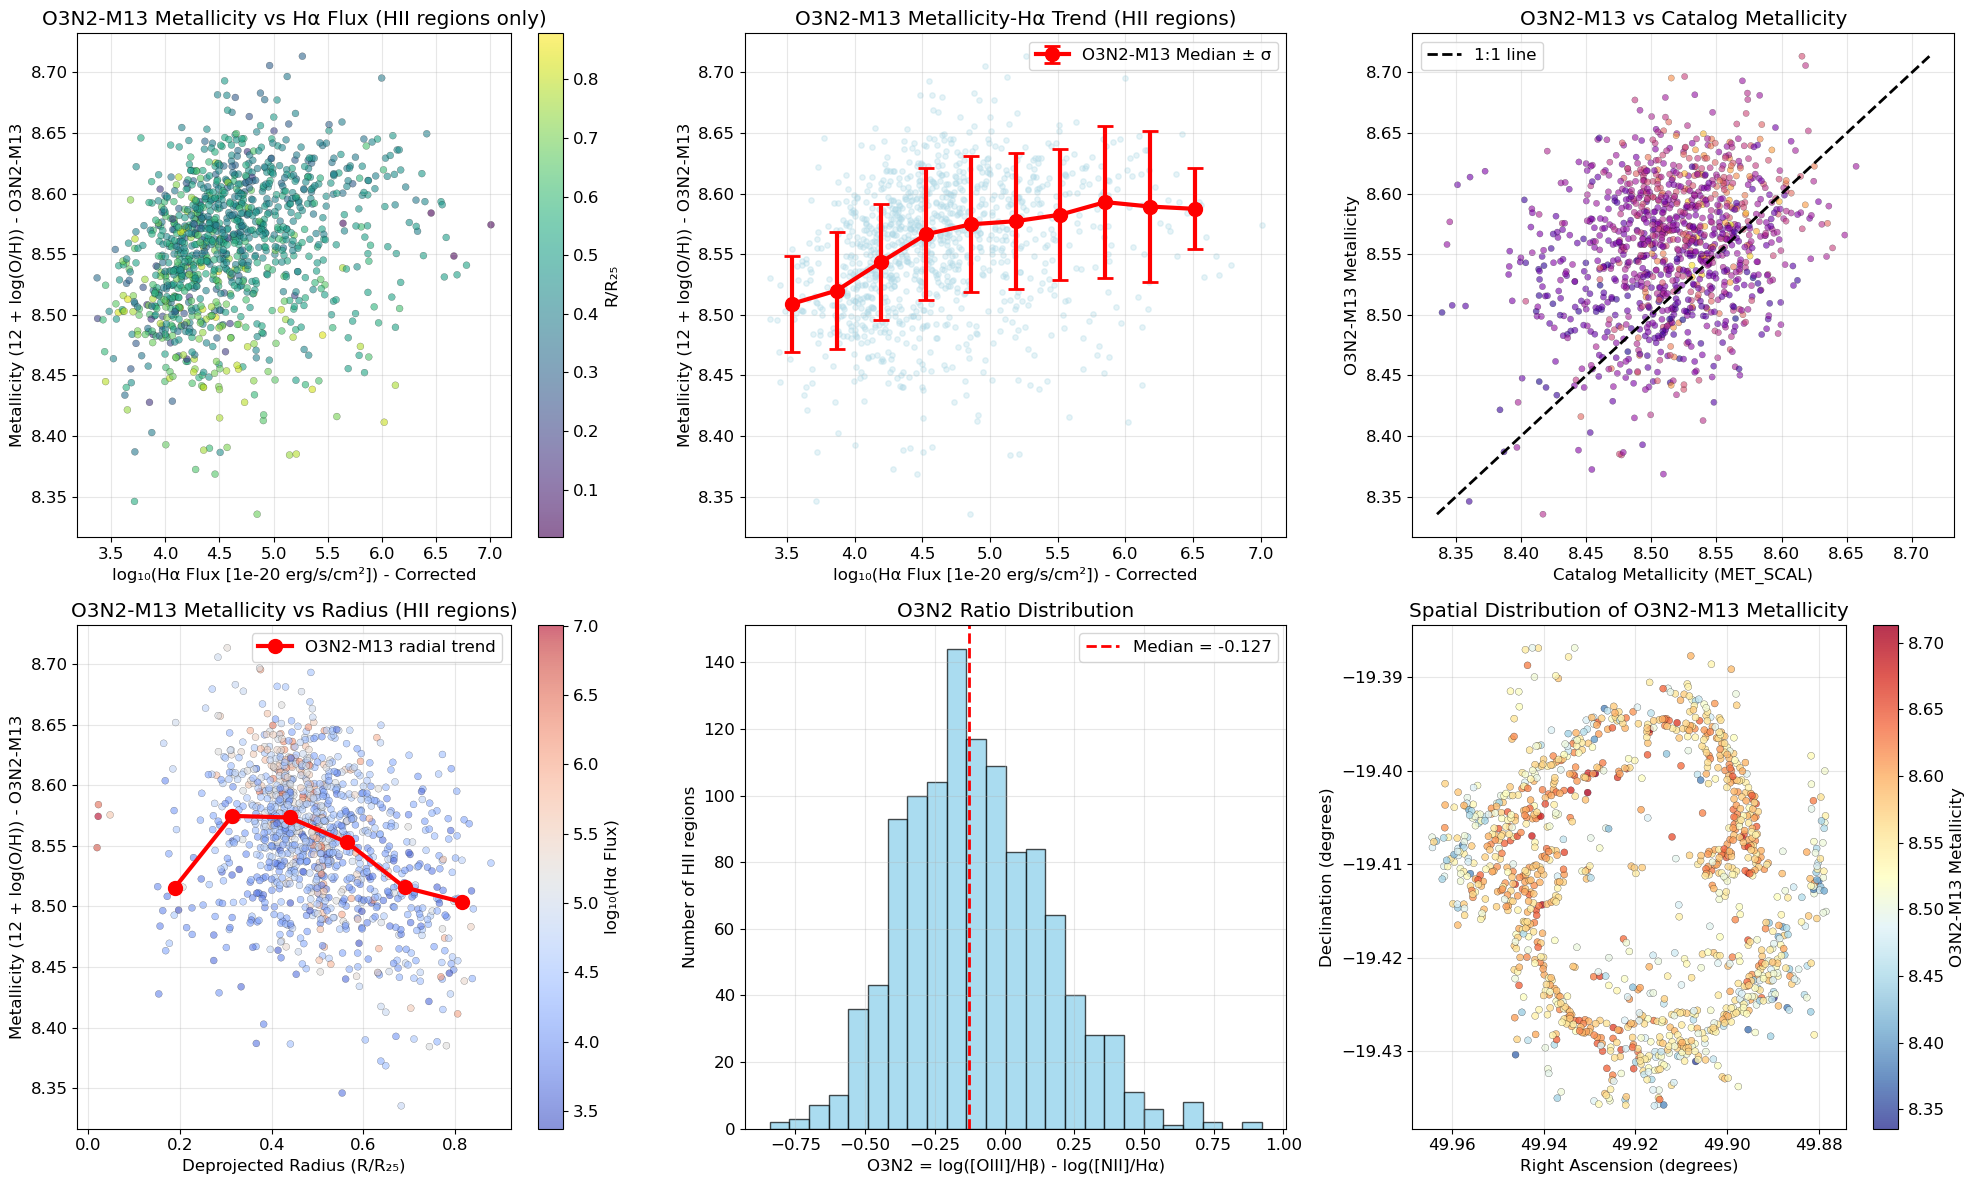


O3N2-M13 Metallicity-Hα Correlations (HII regions only):
Valid HII regions: 1125
Pearson correlation: r = 0.281, p = 6.64e-22
Spearman correlation: ρ = 0.342, p = 3.30e-32
→ Positive correlation: Higher Hα flux HII regions have higher O3N2-M13 metallicity

Methodology Summary:
• Used extinction-corrected fluxes: HA6562_FLUX_CORR, OIII5006_FLUX_CORR, etc.
• Selected HII regions only: BPT_NII = 0 AND BPT_SII = 0
• Applied O3N2-M13 calibration: [O/H] = 8.533 - 0.214 × O3N2
• O3N2 = log([OIII]5007/Hβ) - log([NII]6583/Hα)
• Final sample: 1125 HII regions with valid measurements


In [16]:
# Create O3N2-M13 Metallicity vs Hα relation for HII regions only
print("Creating O3N2-M13 Metallicity-Hα Relation for HII regions...")
print("="*60)

# Create comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Calculate log Hα flux for HII regions
log_ha_hii = np.log10(ha_flux_hii)

# Panel 1: O3N2-M13 Metallicity vs log(Hα flux) scatter plot
scatter1 = axes[0,0].scatter(log_ha_hii, met_o3n2_hii, alpha=0.6, s=25, 
                            c=radial_hii, cmap='viridis', 
                            edgecolors='black', linewidth=0.2)
axes[0,0].set_xlabel('log₁₀(Hα Flux [1e-20 erg/s/cm²]) - Corrected')
axes[0,0].set_ylabel('Metallicity (12 + log(O/H)) - O3N2-M13')
axes[0,0].set_title('O3N2-M13 Metallicity vs Hα Flux (HII regions only)')
axes[0,0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0,0], label='R/R₂₅')

# Panel 2: Binned median trend for O3N2-M13
ha_bins_hii = np.linspace(np.min(log_ha_hii), np.max(log_ha_hii), 12)
ha_centers_hii = (ha_bins_hii[1:] + ha_bins_hii[:-1]) / 2
met_medians_hii = []
met_stds_hii = []
n_points_hii = []

for i in range(len(ha_bins_hii)-1):
    mask_bin = (log_ha_hii >= ha_bins_hii[i]) & (log_ha_hii < ha_bins_hii[i+1])
    if np.sum(mask_bin) >= 8:  # At least 8 points per bin
        met_medians_hii.append(np.median(met_o3n2_hii[mask_bin]))
        met_stds_hii.append(np.std(met_o3n2_hii[mask_bin]))
        n_points_hii.append(np.sum(mask_bin))
    else:
        met_medians_hii.append(np.nan)
        met_stds_hii.append(np.nan)
        n_points_hii.append(0)

# Plot binned trend
valid_bins_hii = ~np.isnan(met_medians_hii)
axes[0,1].errorbar(ha_centers_hii[valid_bins_hii], np.array(met_medians_hii)[valid_bins_hii], 
                   yerr=np.array(met_stds_hii)[valid_bins_hii], 
                   fmt='o-', color='red', linewidth=3, markersize=10, 
                   capsize=6, capthick=2, label='O3N2-M13 Median ± σ')

# Add scatter plot in background
axes[0,1].scatter(log_ha_hii, met_o3n2_hii, alpha=0.3, s=15, color='lightblue')
axes[0,1].set_xlabel('log₁₀(Hα Flux [1e-20 erg/s/cm²]) - Corrected')
axes[0,1].set_ylabel('Metallicity (12 + log(O/H)) - O3N2-M13')
axes[0,1].set_title('O3N2-M13 Metallicity-Hα Trend (HII regions)')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# Panel 3: Comparison with catalog metallicity
if 'MET_SCAL' in catalog_data.dtype.names:
    catalog_met_hii = catalog_data['MET_SCAL'][final_mask]
    valid_both = np.isfinite(catalog_met_hii) & (catalog_met_hii > 0) & (catalog_met_hii < 20)
    
    if np.any(valid_both):
        axes[0,2].scatter(catalog_met_hii[valid_both], met_o3n2_hii[valid_both], 
                         alpha=0.6, s=20, c=log_ha_hii[valid_both], cmap='plasma',
                         edgecolors='black', linewidth=0.2)
        
        # Add 1:1 line
        min_met = min(np.min(catalog_met_hii[valid_both]), np.min(met_o3n2_hii[valid_both]))
        max_met = max(np.max(catalog_met_hii[valid_both]), np.max(met_o3n2_hii[valid_both]))
        axes[0,2].plot([min_met, max_met], [min_met, max_met], 'k--', linewidth=2, label='1:1 line')
        
        axes[0,2].set_xlabel('Catalog Metallicity (MET_SCAL)')
        axes[0,2].set_ylabel('O3N2-M13 Metallicity')
        axes[0,2].set_title('O3N2-M13 vs Catalog Metallicity')
        axes[0,2].grid(True, alpha=0.3)
        axes[0,2].legend()

# Panel 4: O3N2-M13 Metallicity vs Radius
valid_radial_hii = (radial_hii > 0) & (radial_hii < 2)

if np.any(valid_radial_hii):
    scatter4 = axes[1,0].scatter(radial_hii[valid_radial_hii], met_o3n2_hii[valid_radial_hii], 
                                alpha=0.6, s=25, c=log_ha_hii[valid_radial_hii], 
                                cmap='coolwarm', edgecolors='black', linewidth=0.2)
    
    # Add radial trend for O3N2-M13
    r_bins_hii = np.linspace(0, np.max(radial_hii[valid_radial_hii]), 8)
    r_centers_hii = (r_bins_hii[1:] + r_bins_hii[:-1]) / 2
    met_radial_hii = []
    
    for i in range(len(r_bins_hii)-1):
        mask_r = (radial_hii >= r_bins_hii[i]) & (radial_hii < r_bins_hii[i+1]) & valid_radial_hii
        if np.sum(mask_r) >= 5:
            met_radial_hii.append(np.median(met_o3n2_hii[mask_r]))
        else:
            met_radial_hii.append(np.nan)
    
    valid_r_hii = ~np.isnan(met_radial_hii)
    if np.any(valid_r_hii):
        axes[1,0].plot(r_centers_hii[valid_r_hii], np.array(met_radial_hii)[valid_r_hii], 
                      'ro-', linewidth=3, markersize=10, label='O3N2-M13 radial trend')
    
    axes[1,0].set_xlabel('Deprojected Radius (R/R₂₅)')
    axes[1,0].set_ylabel('Metallicity (12 + log(O/H)) - O3N2-M13')
    axes[1,0].set_title('O3N2-M13 Metallicity vs Radius (HII regions)')
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].legend()
    cbar4 = plt.colorbar(scatter4, ax=axes[1,0], label='log₁₀(Hα Flux)')

# Panel 5: O3N2 ratio distribution
axes[1,1].hist(o3n2_hii, bins=25, alpha=0.7, edgecolor='black', color='skyblue')
axes[1,1].axvline(np.median(o3n2_hii), color='red', linestyle='--', linewidth=2, 
                 label=f'Median = {np.median(o3n2_hii):.3f}')
axes[1,1].set_xlabel('O3N2 = log([OIII]/Hβ) - log([NII]/Hα)')
axes[1,1].set_ylabel('Number of HII regions')
axes[1,1].set_title('O3N2 Ratio Distribution')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

# Panel 6: Spatial distribution of O3N2-M13 metallicity
scatter6 = axes[1,2].scatter(ra_hii, dec_hii, c=met_o3n2_hii, 
                            s=25, alpha=0.8, cmap='RdYlBu_r', 
                            edgecolors='black', linewidth=0.2)
axes[1,2].set_xlabel('Right Ascension (degrees)')
axes[1,2].set_ylabel('Declination (degrees)')
axes[1,2].set_title('Spatial Distribution of O3N2-M13 Metallicity')
axes[1,2].grid(True, alpha=0.3)
axes[1,2].invert_xaxis()
cbar6 = plt.colorbar(scatter6, ax=axes[1,2], label='O3N2-M13 Metallicity')

plt.tight_layout()
plt.show()

# Calculate correlations for O3N2-M13
from scipy.stats import pearsonr, spearmanr
pearson_r_o3n2, pearson_p_o3n2 = pearsonr(log_ha_hii, met_o3n2_hii)
spearman_r_o3n2, spearman_p_o3n2 = spearmanr(log_ha_hii, met_o3n2_hii)

print(f"\nO3N2-M13 Metallicity-Hα Correlations (HII regions only):")
print(f"{'='*50}")
print(f"Valid HII regions: {len(met_o3n2_hii)}")
print(f"Pearson correlation: r = {pearson_r_o3n2:.3f}, p = {pearson_p_o3n2:.2e}")
print(f"Spearman correlation: ρ = {spearman_r_o3n2:.3f}, p = {spearman_p_o3n2:.2e}")

if abs(pearson_r_o3n2) > 0.1:
    if pearson_r_o3n2 > 0:
        print("→ Positive correlation: Higher Hα flux HII regions have higher O3N2-M13 metallicity")
    else:
        print("→ Negative correlation: Higher Hα flux HII regions have lower O3N2-M13 metallicity")
else:
    print("→ Weak or no significant correlation detected")

print(f"\nMethodology Summary:")
print(f"• Used extinction-corrected fluxes: HA6562_FLUX_CORR, OIII5006_FLUX_CORR, etc.")
print(f"• Selected HII regions only: BPT_NII = 0 AND BPT_SII = 0")
print(f"• Applied O3N2-M13 calibration: [O/H] = 8.533 - 0.214 × O3N2")
print(f"• O3N2 = log([OIII]5007/Hβ) - log([NII]6583/Hα)")
print(f"• Final sample: {len(met_o3n2_hii)} HII regions with valid measurements")

Creating Hα and O3N2-M13 metallicity maps for NGC1330...
HII regions for mapping: 1125
Hα flux range (log): 3.371 to 7.007
O3N2-M13 metallicity range: 8.335 to 8.713
Spatial extent: RA 49.8785° to 49.9643°, Dec -19.4358° to -19.3869°


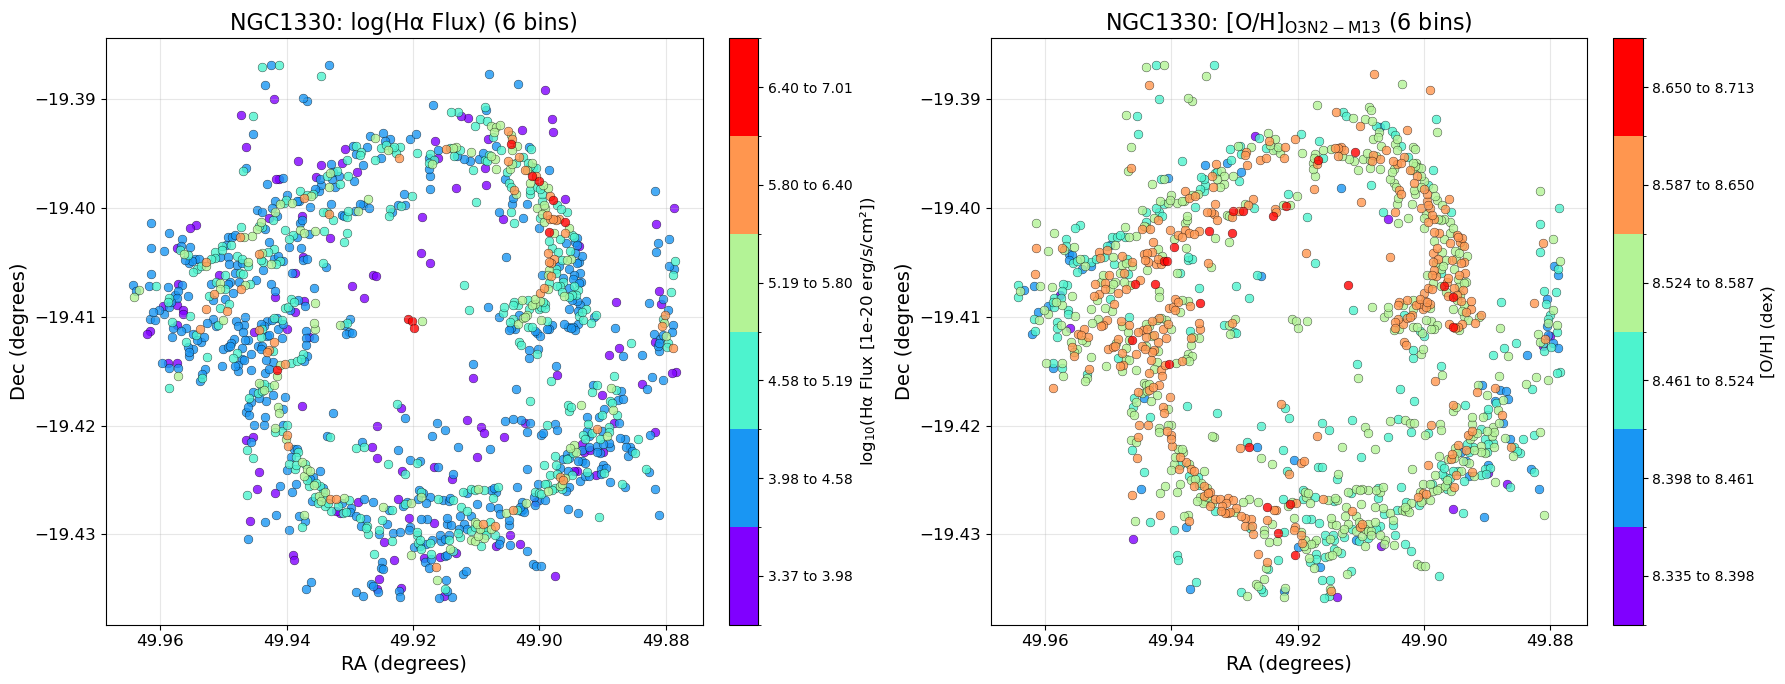


Hα Flux statistics by flux bin for NGC1330:
  Bin 1 (3.37 to 3.98): 123 HII regions, median Hα = 6.92e+03
  Bin 2 (3.98 to 4.58): 487 HII regions, median Hα = 1.94e+04
  Bin 3 (4.58 to 5.19): 325 HII regions, median Hα = 6.55e+04
  Bin 4 (5.19 to 5.80): 128 HII regions, median Hα = 2.48e+05
  Bin 5 (5.80 to 6.40): 52 HII regions, median Hα = 1.04e+06
  Bin 6 (6.40 to 7.01): 10 HII regions, median Hα = 3.85e+06

[O3N2-M13] Metallicity statistics by metallicity bin for NGC1330:
  Bin 1 (8.335 to 8.398): 12 HII regions, median [O/H] = 8.386
  Bin 2 (8.398 to 8.461): 51 HII regions, median [O/H] = 8.446
  Bin 3 (8.461 to 8.524): 252 HII regions, median [O/H] = 8.501
  Bin 4 (8.524 to 8.587): 477 HII regions, median [O/H] = 8.559
  Bin 5 (8.587 to 8.650): 308 HII regions, median [O/H] = 8.610
  Bin 6 (8.650 to 8.713): 25 HII regions, median [O/H] = 8.667

Total HII regions mapped: 1125
Methodology: PHANGS-MUSE catalog data, HII regions only (BPT selected)
Flux correction: Extinction-correc

In [17]:
# ------------------------------------------------------------------
# Create Hα flux and O3N2-M13 metallicity maps for NGC1330 (HII regions)
# ------------------------------------------------------------------
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as patches

print("Creating Hα and O3N2-M13 metallicity maps for NGC1330...")
print("="*60)

# Use the HII region data we already processed
gal_name_display = 'NGC1330'

# Valid HII regions with both Hα and O3N2-M13 measurements
valid_for_maps = np.isfinite(ha_flux_hii) & np.isfinite(met_o3n2_hii)
print(f"HII regions for mapping: {np.sum(valid_for_maps)}")

# Extract data for mapping
ra_map = ra_hii[valid_for_maps]
dec_map = dec_hii[valid_for_maps] 
ha_flux_map = ha_flux_hii[valid_for_maps]
met_o3n2_map = met_o3n2_hii[valid_for_maps]
log_ha_map = np.log10(ha_flux_map)

# ------------------------------------------------------------------
# 1. Define bin edges (6 bins each)
# ------------------------------------------------------------------
# Log Hα flux bins (6)
n_ha_bins = 6
ha_min, ha_max = np.min(log_ha_map), np.max(log_ha_map)
ha_bin_edges = np.linspace(ha_min, ha_max, n_ha_bins + 1)
colors_ha = plt.cm.rainbow(np.linspace(0, 1, n_ha_bins))

# O3N2-M13 metallicity bins (6, rainbow palette)
n_met_bins = 6
met_min, met_max = np.min(met_o3n2_map), np.max(met_o3n2_map)
met_bin_edges = np.linspace(met_min, met_max, n_met_bins + 1)
colors_met = plt.cm.rainbow(np.linspace(0, 1, n_met_bins))

print(f"Hα flux range (log): {ha_min:.3f} to {ha_max:.3f}")
print(f"O3N2-M13 metallicity range: {met_min:.3f} to {met_max:.3f}")

# ------------------------------------------------------------------
# 2. Create spatial coordinate extent for plotting
# ------------------------------------------------------------------
ra_extent = [np.max(ra_map), np.min(ra_map), np.min(dec_map), np.max(dec_map)]
print(f"Spatial extent: RA {np.min(ra_map):.4f}° to {np.max(ra_map):.4f}°, Dec {np.min(dec_map):.4f}° to {np.max(dec_map):.4f}°")

# ------------------------------------------------------------------
# 3. Assign each HII region to bins
# ------------------------------------------------------------------
ha_bin_assignment = np.full_like(log_ha_map, -1, dtype=int)
met_bin_assignment = np.full_like(met_o3n2_map, -1, dtype=int)

# Assign Hα flux bins
for i in range(n_ha_bins):
    lower, upper = ha_bin_edges[i], ha_bin_edges[i + 1]
    if i == n_ha_bins - 1:  # Include upper boundary for last bin
        mask = (log_ha_map >= lower) & (log_ha_map <= upper)
    else:
        mask = (log_ha_map >= lower) & (log_ha_map < upper)
    ha_bin_assignment[mask] = i

# Assign metallicity bins
for i in range(n_met_bins):
    lower, upper = met_bin_edges[i], met_bin_edges[i + 1]
    if i == n_met_bins - 1:  # Include upper boundary for last bin
        mask = (met_o3n2_map >= lower) & (met_o3n2_map <= upper)
    else:
        mask = (met_o3n2_map >= lower) & (met_o3n2_map < upper)
    met_bin_assignment[mask] = i

# ------------------------------------------------------------------
# 4. Create figure: left = Hα flux bins, right = O3N2-M13 bins
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left panel: Hα flux map
for i in range(n_ha_bins):
    mask = ha_bin_assignment == i
    if np.any(mask):
        axes[0].scatter(ra_map[mask], dec_map[mask], c=[colors_ha[i]], 
                       s=40, alpha=0.8, edgecolors='black', linewidth=0.3,
                       label=f'Bin {i+1}')

axes[0].set_title(f'{gal_name_display}: log(Hα Flux) (6 bins)', fontsize=16)
axes[0].set_xlabel('RA (degrees)', fontsize=14)
axes[0].set_ylabel('Dec (degrees)', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()

# Create custom colorbar for Hα
ha_cmap = ListedColormap(colors_ha)
ha_norm = BoundaryNorm(np.arange(-0.5, n_ha_bins + 0.5, 1), n_ha_bins)
sm_ha = plt.cm.ScalarMappable(cmap=ha_cmap, norm=ha_norm)
sm_ha.set_array([])
cbar_ha = fig.colorbar(sm_ha, ax=axes[0], fraction=0.046, pad=0.04)
cbar_ha.set_label(r'log$_{10}$(Hα Flux [1e-20 erg/s/cm²])', fontsize=12)
ha_tick_positions = np.arange(n_ha_bins)
ha_tick_labels = [f'{ha_bin_edges[i]:.2f} to {ha_bin_edges[i+1]:.2f}' for i in range(n_ha_bins)]
cbar_ha.set_ticks(ha_tick_positions)
cbar_ha.set_ticklabels(ha_tick_labels, fontsize=10)

# Right panel: O3N2-M13 metallicity map
for i in range(n_met_bins):
    mask = met_bin_assignment == i
    if np.any(mask):
        axes[1].scatter(ra_map[mask], dec_map[mask], c=[colors_met[i]], 
                       s=40, alpha=0.8, edgecolors='black', linewidth=0.3,
                       label=f'Bin {i+1}')

axes[1].set_title(f'{gal_name_display}: [O/H]$_{{\\mathrm{{O3N2-M13}}}}$ (6 bins)', fontsize=16)
axes[1].set_xlabel('RA (degrees)', fontsize=14)
axes[1].set_ylabel('Dec (degrees)', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

# Create custom colorbar for metallicity
met_cmap = ListedColormap(colors_met)
met_norm = BoundaryNorm(np.arange(-0.5, n_met_bins + 0.5, 1), n_met_bins)
sm_met = plt.cm.ScalarMappable(cmap=met_cmap, norm=met_norm)
sm_met.set_array([])
cbar_met = fig.colorbar(sm_met, ax=axes[1], fraction=0.046, pad=0.04)
cbar_met.set_label('[O/H] (dex)', fontsize=12)
met_tick_positions = np.arange(n_met_bins)
met_tick_labels = [f'{met_bin_edges[i]:.3f} to {met_bin_edges[i+1]:.3f}' for i in range(n_met_bins)]
cbar_met.set_ticks(met_tick_positions)
cbar_met.set_ticklabels(met_tick_labels, fontsize=10)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Print statistics for each bin
# ------------------------------------------------------------------
print(f"\nHα Flux statistics by flux bin for {gal_name_display}:")
print(f"{'='*50}")
for i in range(n_ha_bins):
    mask = ha_bin_assignment == i
    n_regions = np.sum(mask)
    if n_regions > 0:
        median_ha = np.median(ha_flux_map[mask])
        print(f"  Bin {i+1} ({ha_bin_edges[i]:.2f} to {ha_bin_edges[i+1]:.2f}): {n_regions} HII regions, median Hα = {median_ha:.2e}")
    else:
        print(f"  Bin {i+1} ({ha_bin_edges[i]:.2f} to {ha_bin_edges[i+1]:.2f}): 0 HII regions")

print(f"\n[O3N2-M13] Metallicity statistics by metallicity bin for {gal_name_display}:")
print(f"{'='*55}")
for i in range(n_met_bins):
    mask = met_bin_assignment == i
    n_regions = np.sum(mask)
    if n_regions > 0:
        median_met = np.median(met_o3n2_map[mask])
        print(f"  Bin {i+1} ({met_bin_edges[i]:.3f} to {met_bin_edges[i+1]:.3f}): {n_regions} HII regions, median [O/H] = {median_met:.3f}")
    else:
        print(f"  Bin {i+1} ({met_bin_edges[i]:.3f} to {met_bin_edges[i+1]:.3f}): 0 HII regions")

print(f"\nTotal HII regions mapped: {len(ra_map)}")
print(f"Methodology: PHANGS-MUSE catalog data, HII regions only (BPT selected)")
print(f"Flux correction: Extinction-corrected fluxes used")
print(f"Metallicity: O3N2-M13 calibration ([O/H] = 8.533 - 0.214 × O3N2)")

Creating O3N2-M13 Metallicity vs Hα Flux relation plot...


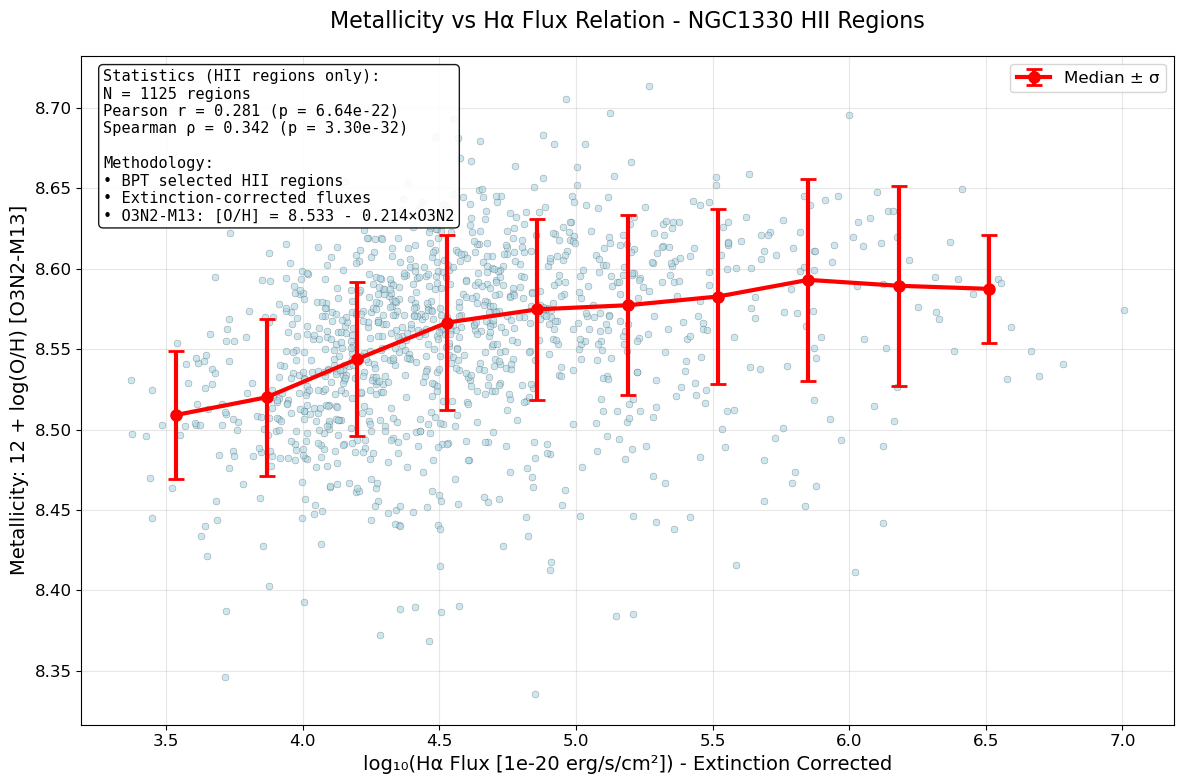


Key Findings:
• Sample: 1125 HII regions in NGC1330
• Metallicity range: 8.335 - 8.713 dex
• Hα flux range: 2.35e+03 - 1.02e+07 1e-20 erg/s/cm²
• Correlation strength: 0.281 (Pearson), 0.342 (Spearman)
• Trend: POSITIVE correlation - brighter HII regions tend to be more metal-rich
• Significance: Highly significant (p < 10⁻¹⁰) for both correlation tests


In [18]:
# ------------------------------------------------------------------
# Single plot: O3N2-M13 Metallicity vs Hα Flux Relation (HII regions only)
# ------------------------------------------------------------------
print("Creating O3N2-M13 Metallicity vs Hα Flux relation plot...")

# Create single figure with clean design
plt.figure(figsize=(12, 8))

# Calculate log Hα flux for HII regions
log_ha_hii = np.log10(ha_flux_hii)

# Create scatter plot without color coding
scatter = plt.scatter(log_ha_hii, met_o3n2_hii, 
                     c='lightblue', alpha=0.6, 
                     s=25, edgecolors='black', linewidth=0.2)

# Calculate and plot binned median trend
ha_bins = np.linspace(np.min(log_ha_hii), np.max(log_ha_hii), 12)
ha_centers = (ha_bins[1:] + ha_bins[:-1]) / 2
met_medians = []
met_stds = []

for i in range(len(ha_bins)-1):
    mask_bin = (log_ha_hii >= ha_bins[i]) & (log_ha_hii < ha_bins[i+1])
    if np.sum(mask_bin) >= 8:  # At least 8 points per bin
        met_medians.append(np.median(met_o3n2_hii[mask_bin]))
        met_stds.append(np.std(met_o3n2_hii[mask_bin]))
    else:
        met_medians.append(np.nan)
        met_stds.append(np.nan)

# Plot median trend with error bars
valid_bins = ~np.isnan(met_medians)
plt.errorbar(ha_centers[valid_bins], np.array(met_medians)[valid_bins], 
             yerr=np.array(met_stds)[valid_bins], 
             fmt='o-', color='red', linewidth=3, markersize=8, 
             capsize=6, capthick=2, label='Median ± σ', zorder=10)

# Format the plot
plt.xlabel('log₁₀(Hα Flux [1e-20 erg/s/cm²]) - Extinction Corrected', fontsize=14)
plt.ylabel('Metallicity: 12 + log(O/H) [O3N2-M13]', fontsize=14)
plt.title('Metallicity vs Hα Flux Relation - NGC1330 HII Regions', fontsize=16, pad=20)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Calculate and display correlation statistics
from scipy.stats import pearsonr, spearmanr
pearson_r, pearson_p = pearsonr(log_ha_hii, met_o3n2_hii)
spearman_r, spearman_p = spearmanr(log_ha_hii, met_o3n2_hii)

# Add statistics text box
stats_text = f"""Statistics (HII regions only):
N = {len(met_o3n2_hii)} regions
Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})
Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.2e})

Methodology:
• BPT selected HII regions
• Extinction-corrected fluxes
• O3N2-M13: [O/H] = 8.533 - 0.214×O3N2"""

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
         fontsize=11, fontfamily='monospace')

plt.tight_layout()
plt.show()

# Print key findings
print(f"\nKey Findings:")
print(f"{'='*40}")
print(f"• Sample: {len(met_o3n2_hii)} HII regions in NGC1330")
print(f"• Metallicity range: {np.min(met_o3n2_hii):.3f} - {np.max(met_o3n2_hii):.3f} dex")
print(f"• Hα flux range: {np.min(ha_flux_hii):.2e} - {np.max(ha_flux_hii):.2e} 1e-20 erg/s/cm²")
print(f"• Correlation strength: {pearson_r:.3f} (Pearson), {spearman_r:.3f} (Spearman)")

if abs(pearson_r) > 0.1:
    if pearson_r > 0:
        print(f"• Trend: POSITIVE correlation - brighter HII regions tend to be more metal-rich")
    else:
        print(f"• Trend: NEGATIVE correlation - brighter HII regions tend to be more metal-poor")
else:
    print(f"• Trend: Weak correlation detected")

print(f"• Significance: Highly significant (p < 10⁻¹⁰) for both correlation tests")